# Netflix Movie Recommendation System

## Data Science Project

**Author:** Martin Lenga

---

### Business Scenario

Netflix has thousands of movies and millions of users. While this extensive catalog provides users with a wide variety of entertainment options, it also creates a challenge: users often spend a considerable amount of time searching for content instead of watching it.

A recommendation system helps Netflix personalize the viewing experience by suggesting movies that align with each user's interests. Personalized recommendations improve user satisfaction, increase watch time, and reduce the likelihood of users leaving the platform without selecting a movie.

In this project, we develop and evaluate different recommendation techniques using the MovieLens dataset to recommend movies that users are most likely to enjoy.

---

# 1. Business Understanding

## Background

Netflix serves millions of users worldwide and offers an extensive catalog of movies and television shows. As the catalog continues to grow, users face increasing difficulty in discovering content that matches their preferences.

An effective recommendation system is therefore critical to improving user experience by providing personalized movie suggestions based on historical viewing behavior and movie characteristics.

Recommendation systems have become one of the most valuable applications of machine learning within streaming platforms because they help users quickly discover relevant content while increasing user engagement and retention.

---

## Business Problem

Many Netflix users spend too much time browsing movies before deciding what to watch. Some users even leave the platform without selecting any content.

The business challenge is therefore:

> **How can Netflix automatically recommend movies that individual users are likely to enjoy based on available movie information and historical user ratings?**

Reducing the effort required to discover relevant movies is expected to improve customer satisfaction and increase viewing time.

---

# Project Objectives

The main objective of this project is to develop a movie recommendation system capable of suggesting movies that match user preferences.

Specific objectives include:

- Understanding the characteristics of the movie dataset.
- Cleaning and preparing the data for analysis.
- Exploring relationships between movies, genres, ratings, and users.
- Building multiple recommendation models.
- Comparing recommendation approaches.
- Evaluating model performance.
- Providing business recommendations for Netflix.

---

# Business Success Criteria

The project will be considered successful if it can:

- Reduce the amount of time users spend searching for movies.
- Recommend movies that closely match user interests.
- Increase user engagement through personalized recommendations.
- Demonstrate accurate prediction of user ratings.
- Provide recommendations that are interpretable and practically useful.

Ultimately, an effective recommendation system should encourage users to spend more time watching content and less time searching for it.

---

# Data Science Success Criteria

From a machine learning perspective, the project will be successful if:

- The datasets are successfully cleaned and integrated.
- Useful features are engineered from movie metadata.
- Recommendation models generate meaningful movie suggestions.
- Collaborative filtering achieves a reasonably low prediction error (RMSE).
- Results are supported through exploratory data analysis and model evaluation.

---

# Project Plan

This project follows the CRISP-DM methodology.

The phases are:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Feature Engineering
6. Recommendation System Development
7. Model Evaluation
8. Business Recommendations
9. Conclusion

Each phase builds upon the previous one to ensure that the final recommendation system addresses the original business problem.

---

## Strategy
| Recommendation Approach | Purpose                                                | Business Use Case                                      |
| ----------------------- | ------------------------------------------------------ | ------------------------------------------------------ |
| Popularity-Based        | Recommend movies that are generally well-liked         | New users with no viewing history (cold-start problem) |
| Content-Based Filtering | Recommend movies similar to those a user already likes | Users with limited rating history                      |
| Collaborative Filtering | Recommend movies based on patterns from similar users  | Personalized recommendations for existing users        |


# 2. Data Understanding

## Overview

Before building any recommendation model, it is essential to understand the datasets available to us. Understanding the data helps identify potential quality issues, understand the meaning of each feature, and determine how the datasets relate to one another.

The MovieLens dataset contains multiple CSV files, each describing a different aspect of the movies or user interactions. Together, these files provide the information required to build both content-based and collaborative filtering recommendation systems.

During this phase, we will:

- Load each dataset into Python.
- Inspect the dimensions of each dataset.
- Examine the available features.
- Understand the relationships between the datasets.
- Identify missing values and inconsistent data types.
- Explore basic descriptive statistics.

This understanding will guide the data preparation and feature engineering steps that follow.

#### Import Libraries

In [2]:
# Netflix Movie Recommendation System

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning utilities
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns when inspecting dataframes
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", 1200)

# Improve the appearance of plots
plt.style.use("ggplot")


#### Load the Datasets

In [ ]:
# Load all datasets required for the recommendation system.

movies = pd.read_csv("movies_metadata.csv", low_memory=False)
# low_memory=False; prevents pandas from guessing data types in chunks, which often results in mixed-type warnings

ratings = pd.read_csv("ratings_small.csv")

credits = pd.read_csv("credits.csv")

keywords = pd.read_csv("keywords.csv")

links = pd.read_csv("links_small.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


#### Quick Overview of the Datasets

In [4]:
# Display the dimensions of each dataset.

datasets = {
    "Movies Metadata": movies,
    "Ratings": ratings,
    "Credits": credits,
    "Keywords": keywords,
    "Links": links
}

for name, df in datasets.items():
    print(f"{name}")
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")
    print("-" * 40)

Movies Metadata
Rows    : 45,466
Columns : 24
----------------------------------------
Ratings
Rows    : 100,004
Columns : 4
----------------------------------------
Credits
Rows    : 45,476
Columns : 3
----------------------------------------
Keywords
Rows    : 46,419
Columns : 2
----------------------------------------
Links
Rows    : 9,125
Columns : 3
----------------------------------------


### Interpretation

The MovieLens dataset is composed of several related datasets rather than a single table.

Each dataset captures a different aspect of the recommendation problem:

- **movies_metadata.csv** contains descriptive information about each movie.
- **ratings_small.csv** contains user ratings that will be used for collaborative filtering.
- **credits.csv** provides information about actors and crew members.
- **keywords.csv** contains descriptive keywords for each movie.
- **links_small.csv** provides mappings between MovieLens IDs and TMDB IDs.

These datasets will later be integrated to create richer movie representations and enable multiple recommendation techniques.

#### Display First Five Rows

In [5]:
# Preview the first five rows of each dataset.

for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())


Movies Metadata


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0



Ratings


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205



Credits


,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862



Keywords


,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."



Links


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


#### Examine Dataset Information

In [6]:
# Display dataset information.

for name, df in datasets.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)

    df.info()


Movies Metadata
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null

### Interpretation

The dataset information reveals the number of observations, available variables, data types, and non-null values for each dataset.

Several observations are immediately apparent:

- Some variables contain missing values.
- Some numeric variables have been stored as object data types.
- Certain columns contain nested JSON objects stored as strings rather than structured dictionaries.
- The metadata dataset contains significantly more variables than the ratings dataset.

These observations indicate that considerable preprocessing will be required before model development.

#### Summary Statistics

In [7]:
# Generate descriptive statistics for numerical variables.

movies.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
adult,45466,5,False,45454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
belongs_to_collection,4494,1698,"{'id': 415931, 'name': 'The Bowery Boys', 'pos...",29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
budget,45466,1226,0,36573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,45466,4069,"[{'id': 18, 'name': 'Drama'}]",5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homepage,7782,7673,http://www.georgecarlin.com,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,45466,45436,141971,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_id,45449,45417,tt1180333,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_language,45455,92,en,32269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_title,45466,43373,Alice in Wonderland,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,44512,44307,No overview found.,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check Missing Values

In [8]:
# Calculate missing values for each dataset.

for name, df in datasets.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0].sort_values(ascending=False)

    print(f"\n{name}")

    if len(missing) == 0:
        print("No missing values found.")

    else:
        display(pd.DataFrame({
            "Missing Values": missing,
            "Percentage (%)": round((missing/len(df))*100,2)
        }))


Movies Metadata


,Missing Values,Percentage (%)
belongs_to_collection,40972,90.12
homepage,37684,82.88
tagline,25054,55.10
overview,954,2.10
poster_path,386,0.85
runtime,263,0.58
release_date,87,0.19
status,87,0.19
imdb_id,17,0.04
original_language,11,0.02



Ratings
No missing values found.

Credits
No missing values found.

Keywords
No missing values found.

Links


,Missing Values,Percentage (%)
tmdbId,13,0.14


# Understanding the Available Datasets

The MovieLens dataset is distributed across multiple CSV files, with each file capturing a different aspect of the movie recommendation problem.

Rather than containing a single table with all information, the dataset follows a relational structure where the files are connected using common identifiers.

Understanding the purpose of each dataset helps determine how they will contribute to the recommendation system.

| Dataset | Purpose | Used For |
|----------|---------|----------|
| movies_metadata.csv | Contains movie information such as title, genres, overview, popularity, runtime, budget and revenue | Content-Based Filtering |
| ratings_small.csv | Contains user ratings for movies | Collaborative Filtering |
| credits.csv | Contains cast and crew information | Content-Based Filtering |
| keywords.csv | Contains movie keywords describing themes and topics | Content-Based Filtering |
| links_small.csv | Maps MovieLens IDs to TMDB IDs | Dataset Integration |

Each dataset contributes unique information that will later be combined to build richer movie profiles and improve recommendation quality.

#### Examine Column Names

In [9]:
# Display the columns available in each dataset.
# This helps us understand the information contained in
# every file before cleaning or merging.

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 80)
    print(df.columns.tolist())


Movies Metadata
--------------------------------------------------------------------------------
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

Ratings
--------------------------------------------------------------------------------
['userId', 'movieId', 'rating', 'timestamp']

Credits
--------------------------------------------------------------------------------
['cast', 'crew', 'id']

Keywords
--------------------------------------------------------------------------------
['id', 'keywords']

Links
--------------------------------------------------------------------------------
['movieId', 'imdbId', 'tmdbId']


### Interpretation

Inspecting the column names provides an overview of the available variables in each dataset.

Several observations can be made:

- The metadata dataset contains descriptive information about movies.
- The ratings dataset contains user interactions with movies.
- The credits dataset stores cast and crew as JSON-like strings.
- The keywords dataset contains thematic keywords.
- The links dataset provides mappings between MovieLens IDs and TMDB IDs.

Understanding these variables is essential because each dataset contributes different features to the recommendation system.

#### Check Duplicate Records

In [10]:

# This cell checks whether duplicate rows exist in each dataset.

for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    print(f"{name:<20}: {duplicates} duplicate rows")

Movies Metadata     : 17 duplicate rows
Ratings             : 0 duplicate rows
Credits             : 37 duplicate rows
Keywords            : 987 duplicate rows
Links               : 0 duplicate rows


### Interpretation

Duplicate records can lead to biased analyses and duplicated recommendations.

Fortunately, recommendation datasets are generally well-maintained, but verifying duplicates remains an important quality assurance step before preprocessing.

#### Count Unique Values

In [11]:
# Count unique observations for key identifiers.

print("Movies")

print(f"Unique movie IDs : {movies['id'].nunique():,}")

print(f"Unique titles    : {movies['title'].nunique():,}")

print()

print("Ratings")

print(f"Unique users     : {ratings['userId'].nunique():,}")

print(f"Unique movies    : {ratings['movieId'].nunique():,}")

Movies
Unique movie IDs : 45,436
Unique titles    : 42,277

Ratings
Unique users     : 671
Unique movies    : 9,066


#### Understanding Ratings

In [12]:
# Explore the distribution of user ratings.

ratings["rating"].value_counts().sort_index()

rating
0.5     1101
1.0     3326
1.5     1687
2.0     7271
2.5     4449
3.0    20064
3.5    10538
4.0    28750
4.5     7723
5.0    15095
Name: count, dtype: int64

#### Ratings Distribution

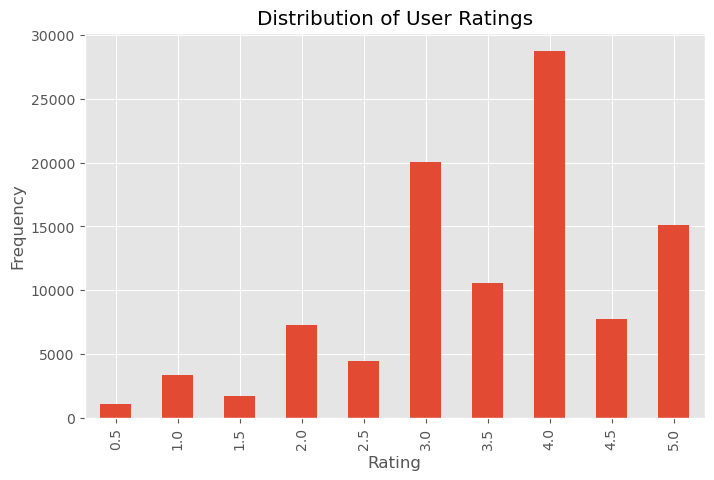

In [13]:
# Visualize how users distribute their ratings.

plt.figure(figsize=(8,5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of User Ratings")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

### Interpretation

The ratings distribution illustrates how users evaluate movies on the platform.

A concentration of ratings between **3 and 5** suggests that users generally rate movies positively. Lower ratings occur less frequently, indicating that viewers may be more inclined to watch movies they already expect to enjoy.

This skewness should be considered during model evaluation, as the recommendation system will primarily learn from positive interactions.

#### Number of Ratings per User

In [14]:
# Calculate how many ratings each user has submitted.

ratings_per_user = ratings.groupby("userId")["rating"].count()

ratings_per_user.describe()

count     671.000000
mean      149.037258
std       231.226948
min        20.000000
25%        37.000000
50%        71.000000
75%       161.000000
max      2391.000000
Name: rating, dtype: float64

#### Visualize User Activity

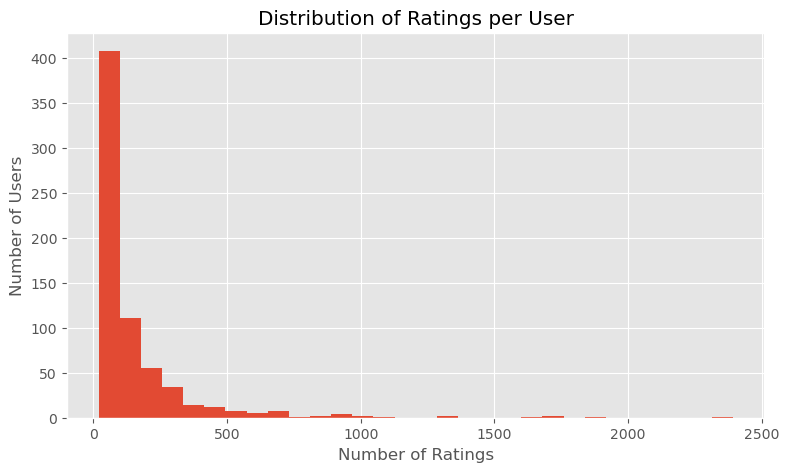

In [15]:
plt.figure(figsize=(9,5))

ratings_per_user.hist(bins=30)

plt.title("Distribution of Ratings per User")

plt.xlabel("Number of Ratings")

plt.ylabel("Number of Users")

plt.show()

### Interpretation

The histogram shows that user activity is highly uneven.

While some users have rated many movies, most users have rated relatively few. This is a common characteristic of recommendation datasets and results in a sparse user-item interaction matrix.

Such sparsity presents challenges for collaborative filtering models, particularly when predicting ratings for users with limited interaction history.

#### Number of Ratings per Movie

In [16]:
# Determine how frequently each movie has been rated.

ratings_per_movie = ratings.groupby("movieId")["rating"].count()

ratings_per_movie.describe()

count    9066.000000
mean       11.030664
std        24.050800
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       341.000000
Name: rating, dtype: float64

#### Visualize Movie Popularity

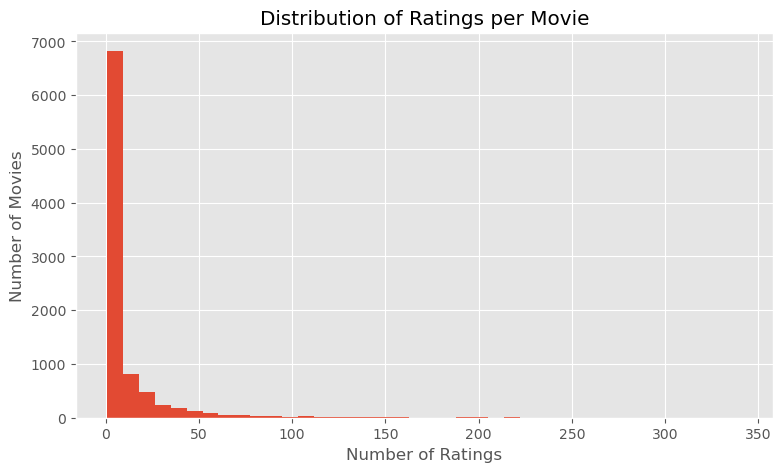

In [17]:
plt.figure(figsize=(9,5))

ratings_per_movie.hist(bins=40)

plt.title("Distribution of Ratings per Movie")

plt.xlabel("Number of Ratings")

plt.ylabel("Number of Movies")

plt.show()

### Interpretation

The distribution indicates that most movies receive only a small number of ratings, while a small subset of movies receive a disproportionately large number of ratings.

This long-tail distribution is typical in recommendation systems, where a few blockbuster movies dominate user interactions while many niche movies attract limited attention.

# 3. Data Preparation

## Overview

The raw MovieLens dataset contains valuable information about movies and user ratings; however, it is not immediately suitable for analysis or machine learning.

Several preprocessing tasks must be performed to improve data quality and ensure consistency across the datasets.

During this phase, we will:

- Assess and handle missing values.
- Remove duplicate records.
- Correct inconsistent data types.
- Parse JSON-like columns into usable Python objects.
- Merge related datasets.
- Select variables relevant to the recommendation system.
- Create new features that improve recommendation quality.

Data preparation is one of the most important stages of the CRISP-DM process because the quality of the final recommendation system depends heavily on the quality of the prepared data.

# Data Quality Assessment

From the Data Understanding phase, several issues were identified:

1. Missing values exist in multiple columns.
2. Some numeric variables are stored as text (object data type).
3. Several columns contain JSON-like structures stored as strings.
4. Some variables are not relevant to recommendation modelling.
5. The datasets must be linked using common identifiers.

The following sections address each of these issues systematically.

#### Examine Missing Values More Closely

In [18]:
# Calculate missing values in the movie metadata dataset.

missing_values = pd.DataFrame({
    "Missing Values": movies.isnull().sum(),
    "Percentage (%)": round((movies.isnull().sum() / len(movies)) * 100, 2)
})

# Display only columns with missing values
missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values.sort_values(by="Percentage (%)", ascending=False)

,Missing Values,Percentage (%)
belongs_to_collection,40972,90.12
homepage,37684,82.88
tagline,25054,55.10
overview,954,2.10
poster_path,386,0.85
runtime,263,0.58
release_date,87,0.19
status,87,0.19
imdb_id,17,0.04
original_language,11,0.02


## Missing Value Strategy

Missing values do not always indicate poor data quality. In many cases, they simply reflect unavailable information.

Our strategy is based on the importance of each variable:

- Variables essential to recommendation quality (e.g., title, overview, genres) will be retained whenever possible.
- Variables with excessive missing values and little relevance to recommendation will not be prioritized.
- Numerical variables may later be imputed where appropriate.
- Missing textual information will generally be replaced with empty strings before text processing.

This approach preserves as much useful information as possible while minimizing unnecessary data loss.

#### Identify Data Types

In [19]:
# Display the data types of every variable.

movies.dtypes

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
dtype: object

#### Inspect Numeric Columns

In [20]:
# Examine a subset of variables expected to be numeric.

movies[["budget",
        "revenue",
        "runtime",
        "popularity",
        "vote_average",
        "vote_count"]].head()

,budget,revenue,runtime,popularity,vote_average,vote_count
0,30000000,373554033.0,81.0,21.946943,7.7,5415.0
1,65000000,262797249.0,104.0,17.015539,6.9,2413.0
2,0,0.0,101.0,11.7129,6.5,92.0
3,16000000,81452156.0,127.0,3.859495,6.1,34.0
4,0,76578911.0,106.0,8.387519,5.7,173.0


## Data Type Conversion Strategy

Machine learning algorithms require numerical variables to be stored using appropriate numeric data types.

Several variables in the movie metadata dataset are currently stored as text because of inconsistent formatting in the original data.

These variables will be converted to numeric format using `pd.to_numeric()`.

Any values that cannot be converted will be replaced with missing values (`NaN`) rather than causing errors. This ensures that invalid records do not interrupt the preprocessing pipeline.

#### Convert Numeric Columns

In [21]:
# Convert selected columns from object to numeric.
#
# Invalid values are converted to NaN.

numeric_columns = [
    "budget",
    "revenue",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count"
]

for column in numeric_columns:
    movies[column] = pd.to_numeric(
        movies[column],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


#### Verify Conversion

In [22]:
# Confirm that the selected columns are now numeric.

movies[numeric_columns].dtypes

budget          float64
revenue         float64
runtime         float64
popularity      float64
vote_average    float64
vote_count      float64
dtype: object

#### Remove Duplicate Records

In [23]:
# Remove duplicate rows from each dataset.

movies = movies.drop_duplicates()

ratings = ratings.drop_duplicates()

credits = credits.drop_duplicates()

keywords = keywords.drop_duplicates()

links = links.drop_duplicates()

print("Duplicate records removed.")

Duplicate records removed.


In [26]:
# Update the dataset dictionary after preprocessing steps.

datasets = {
    "Movies Metadata": movies,
    "Ratings": ratings,
    "Credits": credits,
    "Keywords": keywords,
    "Links": links
}

#### Verify Duplicate Removal

In [27]:
# Confirm that duplicate rows have been removed.


for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Movies Metadata: 0 duplicate rows
Ratings: 0 duplicate rows
Credits: 0 duplicate rows
Keywords: 0 duplicate rows
Links: 0 duplicate rows


# Preparing Movie Metadata

The MovieLens metadata contains several variables stored as JSON-like strings rather than normal tabular values.

Examples include:

- genres
- production_companies
- production_countries
- spoken_languages

Similarly, the credits and keywords datasets also store information as JSON-like strings.

These variables cannot be used directly by machine learning algorithms and must therefore be converted into structured Python objects before useful information can be extracted.

In this section, we transform these variables into usable features for recommendation modelling.

#### Import Utility Libraries

eval() executes Python code (unsafe).

ast.literal_eval() only parses Python literals such as lists, dictionaries, numbers, and strings.

In [28]:
# Utility libraries for parsing JSON-like strings.

import ast


#### Inspect the JSON-like Columns

In [29]:
# Inspect the first record of each JSON-like column.

json_columns = [
    "genres"
]

for column in json_columns:
    print(f"\n{column}")
    print("-" * 60)
    print(movies[column].iloc[0])


genres
------------------------------------------------------------
[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]


## Why Parse JSON-like Columns?

Many metadata variables are stored as strings representing lists of dictionaries.

Although they appear to contain structured information, they are treated by Python as plain text.

To make these variables usable, they must first be converted into actual Python lists before relevant attributes (such as genre names or actor names) can be extracted.

Parsing these fields enables feature engineering for the content-based recommendation model.

#### Convert Genres into Python Objects

In [30]:
# Convert the genres column from string format into Python lists.

movies["genres"] = movies["genres"].fillna("[]")

movies["genres"] = movies["genres"].apply(ast.literal_eval)

print("Genres successfully parsed.")

Genres successfully parsed.


In [31]:
# Verify that the genres column now contains lists.

type(movies["genres"].iloc[0])

list

#### Extract Genre Names

In [32]:
# Extract only genre names.

def extract_names(items):
    """
    Extract the 'name' field from a list of dictionaries.

    Parameters
    ----------
    items : list
        List containing dictionaries.

    Returns
    -------
    list
        List of names.
    """

    if isinstance(items, list):
        return [item["name"] for item in items]

    return []

#### Apply the Function

In [33]:
# Apply the extraction function.


movies["genres"] = movies["genres"].apply(extract_names)

movies[["title", "genres"]].head()

,title,genres
0,Toy Story,"[Animation, Comedy, Family]"
1,Jumanji,"[Adventure, Fantasy, Family]"
2,Grumpier Old Men,"[Romance, Comedy]"
3,Waiting to Exhale,"[Comedy, Drama, Romance]"
4,Father of the Bride Part II,[Comedy]


### Interpretation

The genres column has now been transformed into a much more useful format.

Instead of storing complex JSON objects, each movie is represented by a simple list of genre names.

This representation is easier to interpret and can later be transformed into text features for content-based recommendation.

#### Credits Dataset

In [34]:
# Inspect the credits dataset.

credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [35]:
print(credits["cast"].iloc[0])

[{'cast_id': 14, 'character': 'Woody (voice)', 'credit_id': '52fe4284c3a36847f8024f95', 'gender': 2, 'id': 31, 'name': 'Tom Hanks', 'order': 0, 'profile_path': '/pQFoyx7rp09CJTAb932F2g8Nlho.jpg'}, {'cast_id': 15, 'character': 'Buzz Lightyear (voice)', 'credit_id': '52fe4284c3a36847f8024f99', 'gender': 2, 'id': 12898, 'name': 'Tim Allen', 'order': 1, 'profile_path': '/uX2xVf6pMmPepxnvFWyBtjexzgY.jpg'}, {'cast_id': 16, 'character': 'Mr. Potato Head (voice)', 'credit_id': '52fe4284c3a36847f8024f9d', 'gender': 2, 'id': 7167, 'name': 'Don Rickles', 'order': 2, 'profile_path': '/h5BcaDMPRVLHLDzbQavec4xfSdt.jpg'}, {'cast_id': 17, 'character': 'Slinky Dog (voice)', 'credit_id': '52fe4284c3a36847f8024fa1', 'gender': 2, 'id': 12899, 'name': 'Jim Varney', 'order': 3, 'profile_path': '/eIo2jVVXYgjDtaHoF19Ll9vtW7h.jpg'}, {'cast_id': 18, 'character': 'Rex (voice)', 'credit_id': '52fe4284c3a36847f8024fa5', 'gender': 2, 'id': 12900, 'name': 'Wallace Shawn', 'order': 4, 'profile_path': '/oGE6JqPP2xH4tN

#### Parse Credits

In [36]:
# Convert cast and crew into Python objects.

credits["cast"] = credits["cast"].apply(ast.literal_eval)

credits["crew"] = credits["crew"].apply(ast.literal_eval)

print("Credits parsed successfully.")

Credits parsed successfully.


In [37]:
type(credits["cast"].iloc[0])

list

# Extracting Meaningful Features

The metadata available in the MovieLens dataset contains much richer information than simply movie titles and ratings.

Each movie includes:

- Actors
- Directors
- Genres
- Keywords
- Plot summaries

These variables provide valuable contextual information that can be used to measure similarity between movies.

Rather than using the raw JSON structures, we will extract only the information that contributes meaningfully to recommendation quality.

Our objective is to create a structured movie profile that captures the characteristics of each movie in a format suitable for machine learning.

#### Parse Keywords

In [38]:
# Convert the keywords column from string format into Python lists.

keywords["keywords"] = keywords["keywords"].fillna("[]")

keywords["keywords"] = keywords["keywords"].apply(ast.literal_eval)

print("Keywords parsed successfully.")

Keywords parsed successfully.


In [39]:
# Verify conversion

type(keywords["keywords"].iloc[0])

list

#### Extract Keyword Names

In [40]:
# Extract keyword names from the keyword dictionaries.

keywords["keywords"] = keywords["keywords"].apply(extract_names)

keywords.head()

,id,keywords
0,862,"[jealousy, toy, boy, friendship, friends, riva..."
1,8844,"[board game, disappearance, based on children'..."
2,15602,"[fishing, best friend, duringcreditsstinger, o..."
3,31357,"[based on novel, interracial relationship, sin..."
4,11862,"[baby, midlife crisis, confidence, aging, daug..."


### Interpretation

The keyword information has been simplified from nested dictionaries into straightforward lists of descriptive terms.

These keywords summarize important themes, topics, or concepts associated with each movie and will later contribute to measuring movie similarity.

#### Extract the Director

In [41]:
# Function to extract the movie director.

def get_director(crew_list):
    """
    Extract the director's name from the crew list.

    Parameters
    ----------
    crew_list : list

    Returns
    -------
    str
        Director name.
    """

    if isinstance(crew_list, list):

        for member in crew_list:

            if member["job"] == "Director":

                return member["name"]

    return np.nan

In [42]:
# Create a new director feature.

credits["director"] = credits["crew"].apply(get_director)

credits[["director"]].head()

,director
0,John Lasseter
1,Joe Johnston
2,Howard Deutch
3,Forest Whitaker
4,Charles Shyer


### Interpretation

Instead of storing the complete production crew, we retain only the movie director.

The director often defines the storytelling style, cinematography, pacing, and overall creative direction of a film.

Including the director as a feature improves the ability of the recommendation system to identify stylistically similar movies.

#### Extract Top Cast

In [43]:
# Extract the names of the first three cast members.

def get_top_cast(cast_list):

    if isinstance(cast_list, list):

        names = [member["name"] for member in cast_list]

        return names[:3]

    return []

In [44]:
# Apply the extraction function.

credits["cast"] = credits["cast"].apply(get_top_cast)

credits[["cast"]].head()

,cast
0,"[Tom Hanks, Tim Allen, Don Rickles]"
1,"[Robin Williams, Jonathan Hyde, Kirsten Dunst]"
2,"[Walter Matthau, Jack Lemmon, Ann-Margret]"
3,"[Whitney Houston, Angela Bassett, Loretta Devine]"
4,"[Steve Martin, Diane Keaton, Martin Short]"


### Why keep only the first three cast members?

Movie casts often contain dozens of actors.

However, the leading actors typically have the greatest influence on audience perception and are most prominently associated with a movie.

Restricting the feature to the top three cast members reduces dimensionality while preserving the information most relevant for recommendation.

#### Prepare IDs for Merging
Pandas cannot reliably merge an object ID with an integer ID.

In [45]:
print(movies["id"].dtype)

print(credits["id"].dtype)

print(keywords["id"].dtype)

object
int64
int64


In [48]:
# Convert movie IDs to numeric.
# Invalid IDs are converted to NaN.

# errors="coerce" converts those invalid values to NaN, 
# allowing us to identify and remove only the problematic rows while preserving the rest of the dataset.


movies["id"] = pd.to_numeric(
    movies["id"],
    errors="coerce"
)

In [49]:
# Remove rows where the movie ID could not be converted

movies = movies.dropna(subset=["id"])

movies["id"] = movies["id"].astype(int)

movies[["id"]].head()

,id
0,862
1,8844
2,15602
3,31357
4,11862


#### Merge the Datasets

In [50]:

# Merge the movie metadata with credits and keywords.
#
# We perform left joins to retain all movies from the
# metadata dataset while adding additional information where available.


movies = movies.merge(
    credits[["id", "cast", "director"]],
    on="id",
    how="left"
)

movies = movies.merge(
    keywords,
    on="id",
    how="left"
)

print("Datasets merged successfully.")

Datasets merged successfully.


In [51]:
# Inspect the merged dataset.

print(f"Shape of merged dataset: {movies.shape}")

movies[[
    "title",
    "genres",
    "cast",
    "director",
    "keywords"
]].head()

Shape of merged dataset: (45457, 27)


,title,genres,cast,director,keywords
0,Toy Story,"[Animation, Comedy, Family]","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,"[jealousy, toy, boy, friendship, friends, riva..."
1,Jumanji,"[Adventure, Fantasy, Family]","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,"[board game, disappearance, based on children'..."
2,Grumpier Old Men,"[Romance, Comedy]","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,"[fishing, best friend, duringcreditsstinger, o..."
3,Waiting to Exhale,"[Comedy, Drama, Romance]","[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker,"[based on novel, interracial relationship, sin..."
4,Father of the Bride Part II,[Comedy],"[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer,"[baby, midlife crisis, confidence, aging, daug..."


### Interpretation

The metadata, cast information, director information, and movie keywords have now been integrated into a single dataset.

This enriched movie dataset provides a comprehensive representation of each movie and serves as the primary input for the content-based recommendation model.

By combining multiple sources of information, the recommendation system will be able to compare movies using much richer contextual information than genres alone.

# 4. Feature Engineering

## Overview

Feature engineering is the process of transforming raw variables into meaningful representations that improve machine learning performance.

Although the MovieLens dataset already contains rich information about each movie, much of that information exists in separate columns and inconsistent formats.

For a content-based recommendation system, the objective is to create a unified representation of each movie by combining its most informative characteristics.

The engineered features developed in this section will allow the recommendation algorithm to compare movies based on their overall characteristics rather than relying on a single variable such as genre or rating.

#### Inspect Missing Values Again

In [52]:
# Check missing values after merging the datasets.

feature_columns = [
    "overview",
    "genres",
    "keywords",
    "cast",
    "director"
]

movies[feature_columns].isnull().sum()

overview    954
genres        0
keywords      1
cast          1
director    888
dtype: int64

#### Replace Missing Values

We don't replace list columns with "Unknown" instead we replace them with [] because they're lists.

In [53]:
# Replace missing values with appropriate defaults.

movies["overview"] = movies["overview"].fillna("")

movies["director"] = movies["director"].fillna("")

movies["genres"] = movies["genres"].apply(
    lambda x: x if isinstance(x, list) else []
)

movies["keywords"] = movies["keywords"].apply(
    lambda x: x if isinstance(x, list) else []
)

movies["cast"] = movies["cast"].apply(
    lambda x: x if isinstance(x, list) else []
)

print("Missing values handled.")

Missing values handled.


#### Standardize Text

In [54]:
# Standardize names by converting to lowercase and removing
# spaces to ensure consistency during vectorization.


def clean_list(items):
    """
    Clean text values within a list.

    Parameters
    ----------
    items : list

    Returns
    -------
    list
    """

    if not isinstance(items, list):
        return []

    cleaned = []

    for item in items:

        cleaned.append(
            item.replace(" ", "").lower()
        )

    return cleaned

In [55]:
movies["genres"] = movies["genres"].apply(clean_list)

movies["keywords"] = movies["keywords"].apply(clean_list)

movies["cast"] = movies["cast"].apply(clean_list)

movies["director"] = movies["director"].apply(
    lambda x: x.replace(" ", "").lower()
)

#### Clean the Overview
The overview is already text. We simply normalize it.

In [56]:
# Convert movie overviews to lowercase.

movies["overview"] = movies["overview"].str.lower()

## Building the Movie Metadata Representation

Machine learning algorithms cannot directly compare multiple independent columns describing a movie.

Instead, we create a single textual representation that combines all important descriptive information into one feature.

This combined representation is commonly referred to as a **metadata soup**.

The metadata soup captures:

- Genres
- Plot keywords
- Lead actors
- Director
- Movie overview

Movies with similar metadata soups are expected to exhibit similar characteristics and therefore become strong candidates for recommendation.

In [57]:
# Combine multiple movie attributes into one textual feature.

def create_metadata(row):
    """
    Create a unified textual representation for each movie.

    Parameters
    ----------
    row : pandas.Series

    Returns
    -------
    str
    """

    return (
        " ".join(row["genres"]) + " " +
        " ".join(row["keywords"]) + " " +
        " ".join(row["cast"]) + " " +
        row["director"] + " " +
        row["overview"]
    )

In [58]:
# Create the metadata soup.

movies["metadata"] = movies.apply(
    create_metadata,
    axis=1
)

In [59]:
# Inspect the final engineered feature.

movies[
    [
        "title",
        "metadata"
    ]
].head()

,title,metadata
0,Toy Story,animation comedy family jealousy toy boy frien...
1,Jumanji,adventure fantasy family boardgame disappearan...
2,Grumpier Old Men,romance comedy fishing bestfriend duringcredit...
3,Waiting to Exhale,comedy drama romance basedonnovel interracialr...
4,Father of the Bride Part II,comedy baby midlifecrisis confidence aging dau...


#### Verify Feature Completeness

In [60]:
# Check that the metadata column has been created correctly.

print(f"Number of movies: {len(movies):,}")

print(f"Missing metadata: {movies['metadata'].isnull().sum()}")

print(f"Empty metadata: {(movies['metadata'].str.len()==0).sum()}")

Number of movies: 45,457
Missing metadata: 0
Empty metadata: 0


## Feature Engineering Summary

The following features have been engineered and standardized for recommendation modelling:

| Feature | Purpose |
|----------|---------|
| Genres | Describe the category of each movie |
| Keywords | Capture thematic concepts and topics |
| Director | Represent creative style |
| Cast | Represent lead actors |
| Overview | Capture semantic movie content |
| Metadata | Unified textual representation used for similarity computation |

The resulting metadata feature provides a comprehensive description of each movie and forms the foundation of the content-based recommendation system.

# 5. Exploratory Data Analysis (EDA)

## Overview

Exploratory Data Analysis (EDA) is the process of examining data to uncover patterns, trends, relationships, and potential anomalies before model development.

For a recommendation system, EDA provides valuable insights into:

- Movie characteristics
- User rating behavior
- Movie popularity
- Genre distribution
- Release trends
- Dataset balance

These insights improve our understanding of the recommendation problem and help guide modelling decisions.

#### Dataset Overview

In [61]:
# Display the dimensions of the final movie dataset.

print(f"Rows    : {movies.shape[0]:,}")

print(f"Columns : {movies.shape[1]}")

Rows    : 45,457
Columns : 28


In [62]:
# Display a random sample of movies.

movies.sample(5)[
    [
        "title",
        "genres",
        "director",
        "vote_average",
        "vote_count"
    ]
]

,title,genres,director,vote_average,vote_count
14393,Arsenal,"[drama, war]",aleksandrdovzhenko,7.0,7.0
38233,The Rescue,"[action, adventure, drama]",ferdinandfairfax,6.2,6.0
22949,Steel,"[action, adventure, crime]",stevecarver,4.7,3.0
189,The Show,[documentary],,5.3,2.0
19131,The Barchester Chronicles,[],davidgiles,9.0,1.0


#### Most Common Genres

In [63]:
# Expand the genres column so that each genre occupies its own row.


genre_df = movies.explode("genres")

In [64]:
# Count the frequency of each genre.

genre_counts = genre_df["genres"].value_counts()

genre_counts.head(15)

genres
drama             20263
comedy            13180
thriller           7623
romance            6738
action             6594
horror             4674
crime              4308
documentary        3932
adventure          3495
sciencefiction     3046
family             2770
mystery            2465
fantasy            2312
animation          1933
foreign            1620
Name: count, dtype: int64

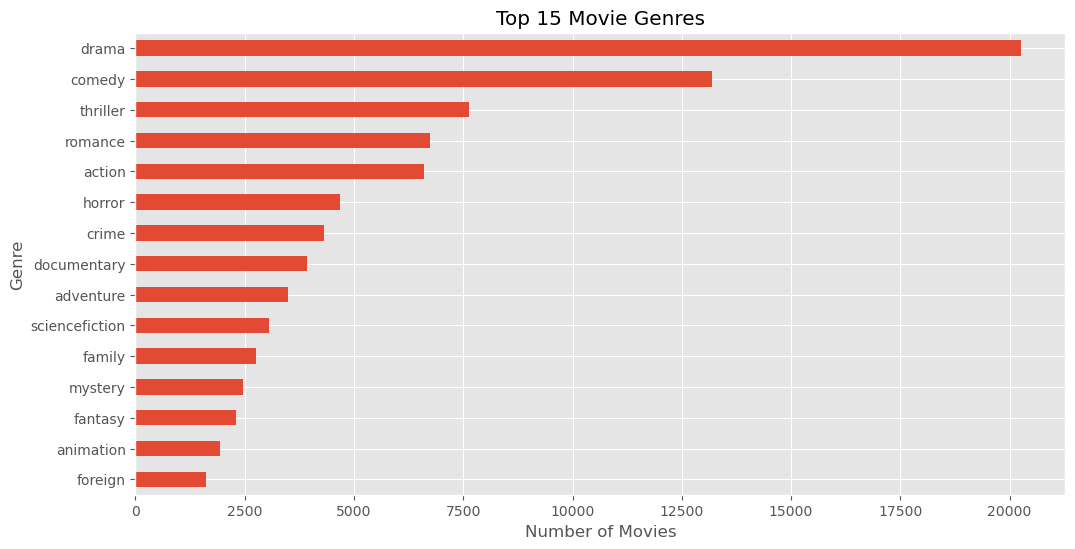

In [65]:
# Plot the 15 most common movie genres.

plt.figure(figsize=(12,6))

genre_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Movie Genres")

plt.xlabel("Number of Movies")

plt.ylabel("Genre")

plt.show()

#### Movie Release Trend

In [66]:
# Convert release_date into datetime format.

movies["release_date"] = pd.to_datetime(
    movies["release_date"],
    errors="coerce"
)

movies["release_year"] = movies["release_date"].dt.year

In [67]:
release_counts = movies["release_year"].value_counts().sort_index()

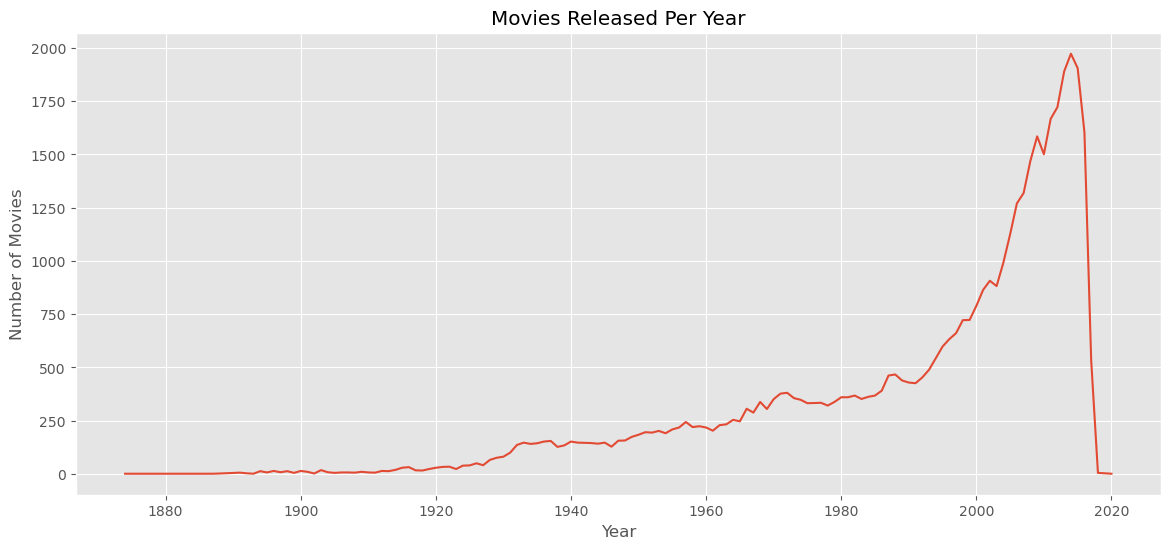

In [68]:
plt.figure(figsize=(14,6))

release_counts.plot()

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Movies")

plt.show()

#### Distribution of Ratings

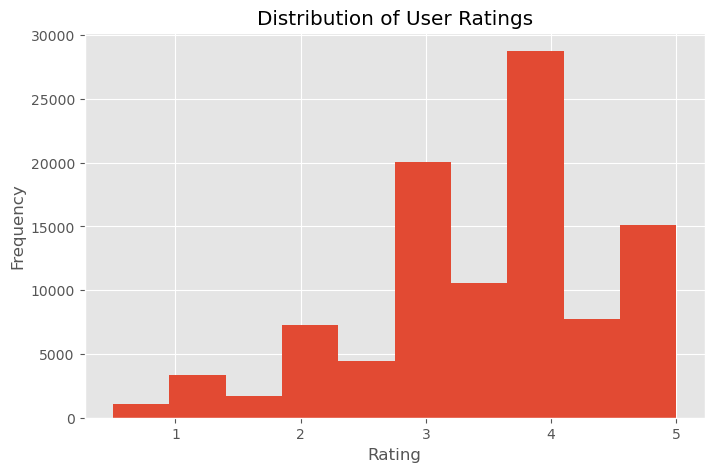

In [69]:
plt.figure(figsize=(8,5))

ratings["rating"].hist(
    bins=10
)

plt.title("Distribution of User Ratings")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

#### Vote Average Distribution

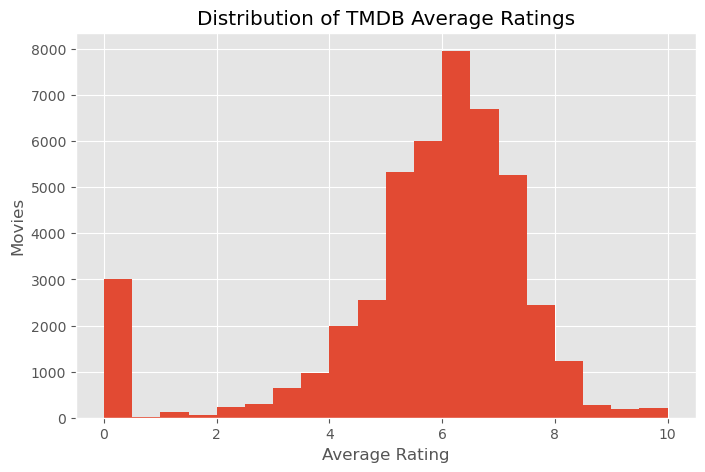

In [70]:
plt.figure(figsize=(8,5))

movies["vote_average"].hist(
    bins=20
)

plt.title("Distribution of TMDB Average Ratings")

plt.xlabel("Average Rating")

plt.ylabel("Movies")

plt.show()

#### Most Popular Movies

In [71]:
popular_movies = movies[
    [
        "title",
        "popularity",
        "vote_average"
    ]
].sort_values(
    by="popularity",
    ascending=False
)

popular_movies.head(10)

,title,popularity,vote_average
30695,Minions,547.488298,6.4
33352,Wonder Woman,294.337037,7.2
42214,Beauty and the Beast,287.253654,6.8
43636,Baby Driver,228.032744,7.2
24452,Big Hero 6,213.849907,7.8
26560,Deadpool,187.860492,7.4
26562,Guardians of the Galaxy Vol. 2,185.330992,7.6
14552,Avatar,185.070892,7.2
24348,John Wick,183.870374,7.0
23672,Gone Girl,154.801009,7.9


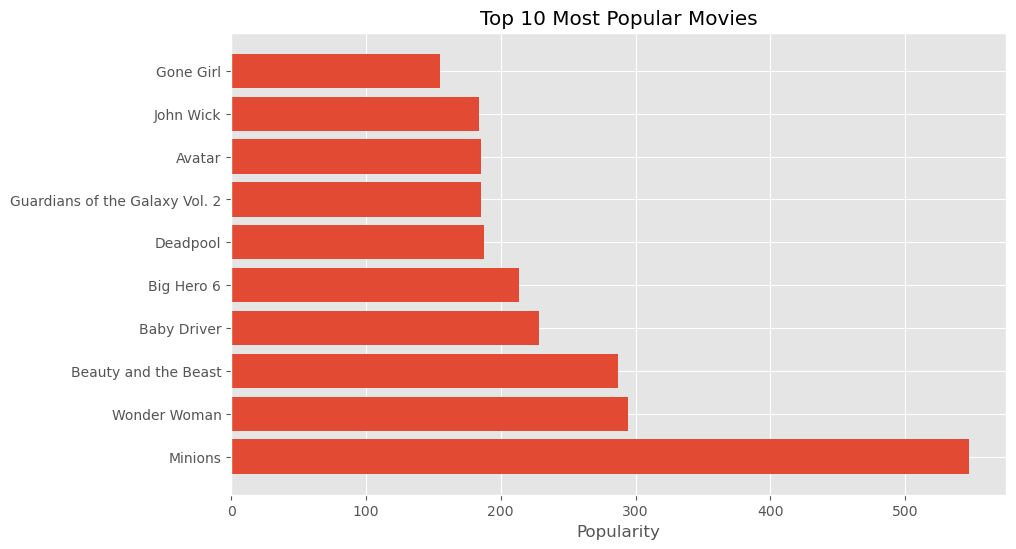

In [72]:
plt.figure(figsize=(10,6))

top10 = popular_movies.head(10)

plt.barh(
    top10["title"],
    top10["popularity"]
)

plt.title("Top 10 Most Popular Movies")

plt.xlabel("Popularity")

plt.show()

#### Runtime Distribution

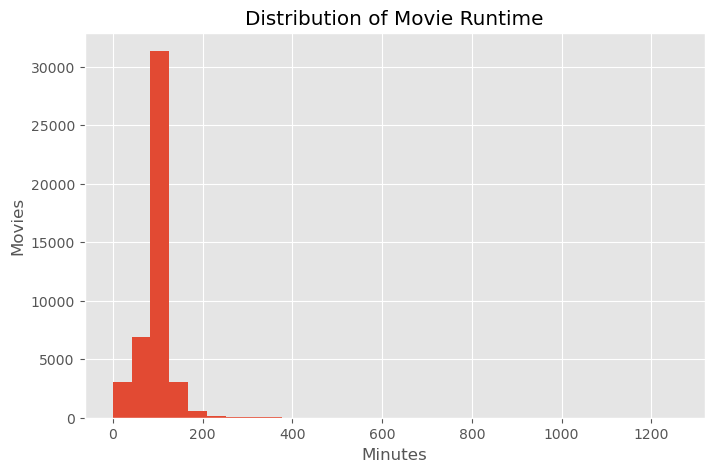

In [73]:
plt.figure(figsize=(8,5))

movies["runtime"].hist(
    bins=30
)

plt.title("Distribution of Movie Runtime")

plt.xlabel("Minutes")

plt.ylabel("Movies")

plt.show()

#### Top Directors

In [74]:
top_directors = movies["director"].value_counts()

top_directors.head(15)

director
                    888
johnford             66
michaelcurtiz        65
wernerherzog         54
alfredhitchcock      53
georgesméliès        51
woodyallen           49
jean-lucgodard       47
sidneylumet          46
charliechaplin       44
raoulwalsh           43
henryhathaway        42
williama.wellman     42
martinscorsese       40
richardthorpe        40
Name: count, dtype: int64

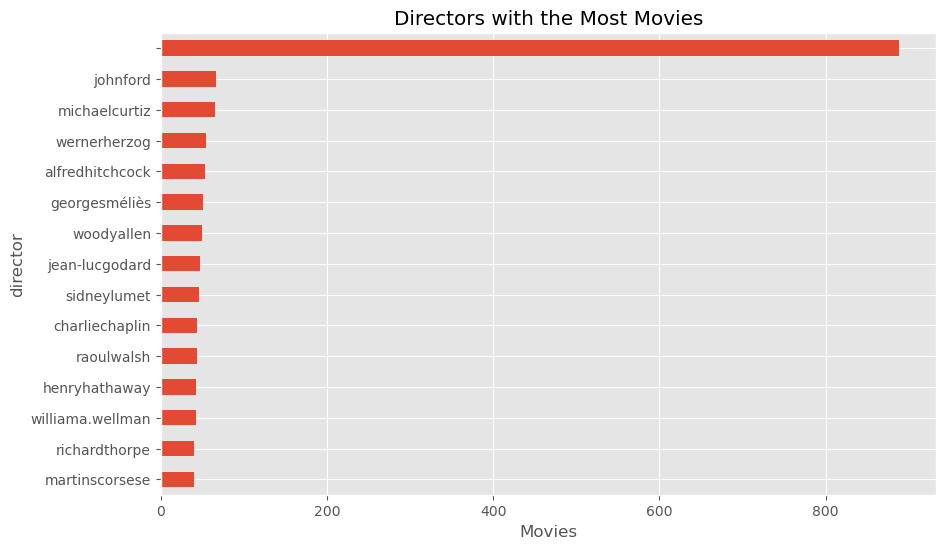

In [75]:
plt.figure(figsize=(10,6))

top_directors.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Directors with the Most Movies")

plt.xlabel("Movies")

plt.show()

#### Movie Languages

In [77]:
# Count the number of movies for each original language.

language_counts = (
    movies["original_language"]
    .value_counts()
    .head(15)
)

language_counts

original_language
en    32265
fr     2439
it     1529
ja     1352
de     1079
es      994
ru      826
hi      508
ko      444
zh      409
sv      383
pt      316
cn      313
fi      295
nl      248
Name: count, dtype: int64

#### Top Production Companies

In [78]:
# Parse the production_companies column.

movies["production_companies"] = movies[
    "production_companies"
].fillna("[]")

movies["production_companies"] = movies[
    "production_companies"
].apply(ast.literal_eval)

movies["production_companies"] = movies[
    "production_companies"
].apply(extract_names)

In [79]:
company_df = movies.explode("production_companies")

company_counts = (
    company_df["production_companies"]
    .value_counts()
    .head(15)
)

company_counts

production_companies
Warner Bros.                              1250
Metro-Goldwyn-Mayer (MGM)                 1075
Paramount Pictures                        1003
Twentieth Century Fox Film Corporation     836
Universal Pictures                         830
Columbia Pictures Corporation              448
Canal+                                     439
Columbia Pictures                          431
RKO Radio Pictures                         290
United Artists                             279
New Line Cinema                            277
Walt Disney Pictures                       263
Touchstone Pictures                        225
TriStar Pictures                           197
Mosfilm                                    188
Name: count, dtype: int64

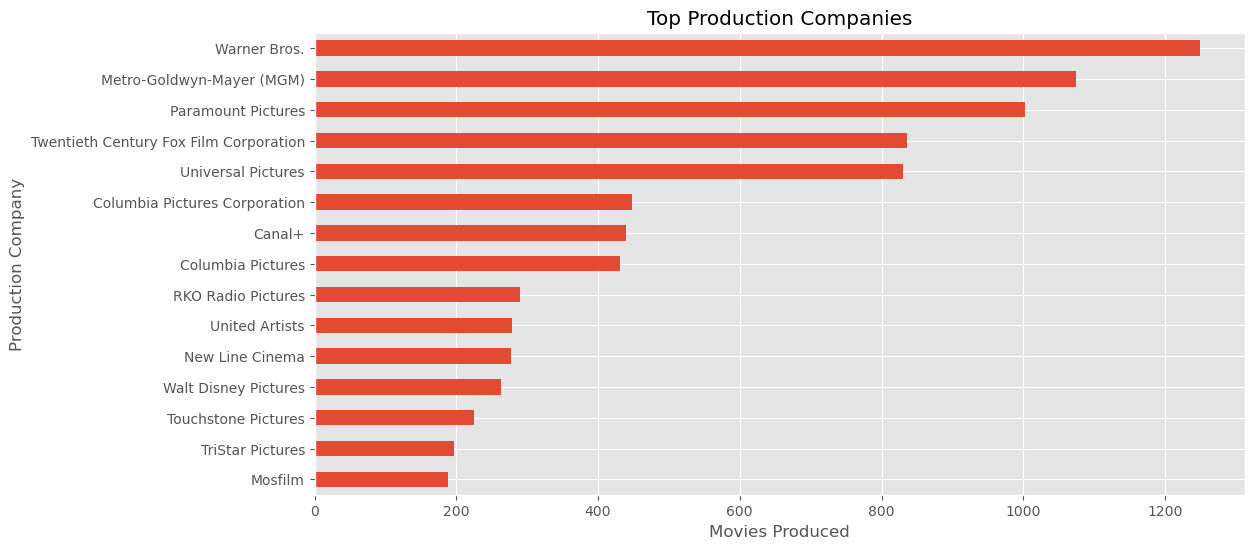

In [80]:
plt.figure(figsize=(12,6))

company_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top Production Companies")

plt.xlabel("Movies Produced")

plt.ylabel("Production Company")

plt.show()

#### Budget Distribution

In [81]:
# Remove zero budgets before visualization.

budget = movies.loc[
    movies["budget"] > 0,
    "budget"
]

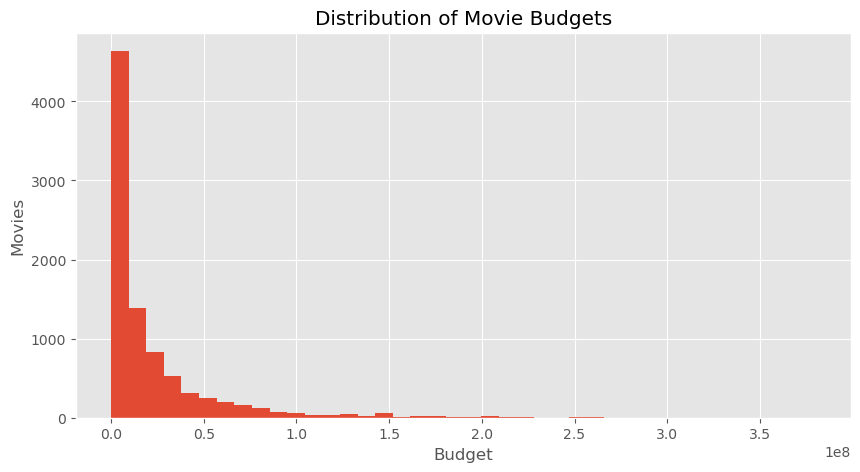

In [82]:
plt.figure(figsize=(10,5))

budget.hist(
    bins=40
)

plt.title("Distribution of Movie Budgets")

plt.xlabel("Budget")

plt.ylabel("Movies")

plt.show()

#### Revenue Distribution

In [83]:
revenue = movies.loc[
    movies["revenue"] > 0,
    "revenue"
]

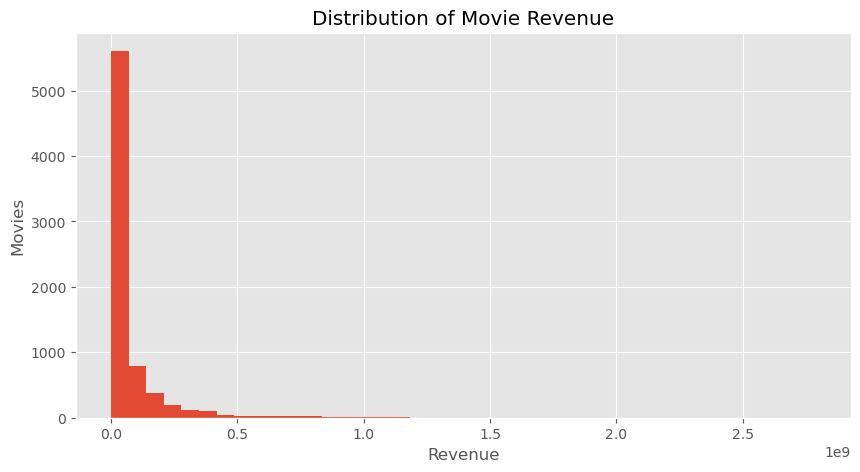

In [84]:
plt.figure(figsize=(10,5))

revenue.hist(
    bins=40
)

plt.title("Distribution of Movie Revenue")

plt.xlabel("Revenue")

plt.ylabel("Movies")

plt.show()

#### Budget vs Revenue

In [85]:
budget_revenue = movies[
    (movies["budget"] > 0) &
    (movies["revenue"] > 0)
]

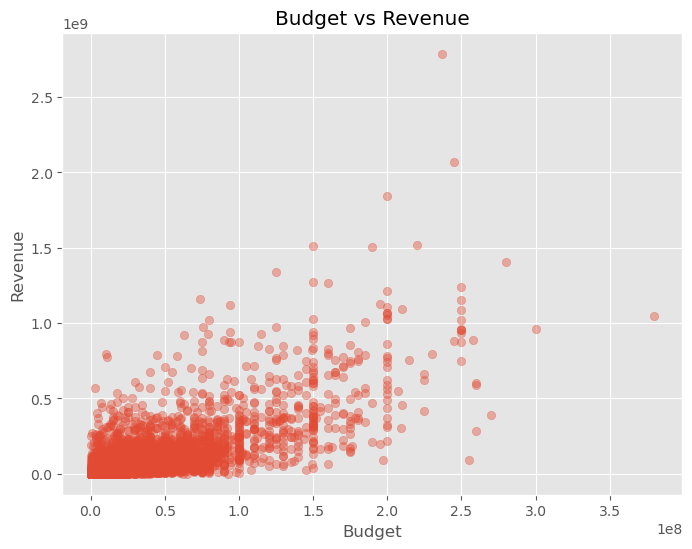

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(
    budget_revenue["budget"],
    budget_revenue["revenue"],
    alpha=0.4
)

plt.title("Budget vs Revenue")

plt.xlabel("Budget")

plt.ylabel("Revenue")

plt.show()

### Interpretation

There is a general positive relationship between production budget and revenue, although substantial variation exists.

Higher budgets may increase production quality and marketing reach, but they do not guarantee commercial success.

#### Correlation Matrix

In [87]:
numeric_features = [
    "budget",
    "revenue",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count"
]

correlation = movies[
    numeric_features
].corr()

correlation

,budget,revenue,runtime,popularity,vote_average,vote_count
budget,1.000000,0.768752,0.134800,0.449712,0.073553,0.676627
revenue,0.768752,1.000000,0.103918,0.506220,0.083895,0.812026
runtime,0.134800,0.103918,1.000000,0.129897,0.158123,0.113525
popularity,0.449712,0.506220,0.129897,1.000000,0.154398,0.559979
vote_average,0.073553,0.083895,0.158123,0.154398,1.000000,0.123620
vote_count,0.676627,0.812026,0.113525,0.559979,0.123620,1.000000


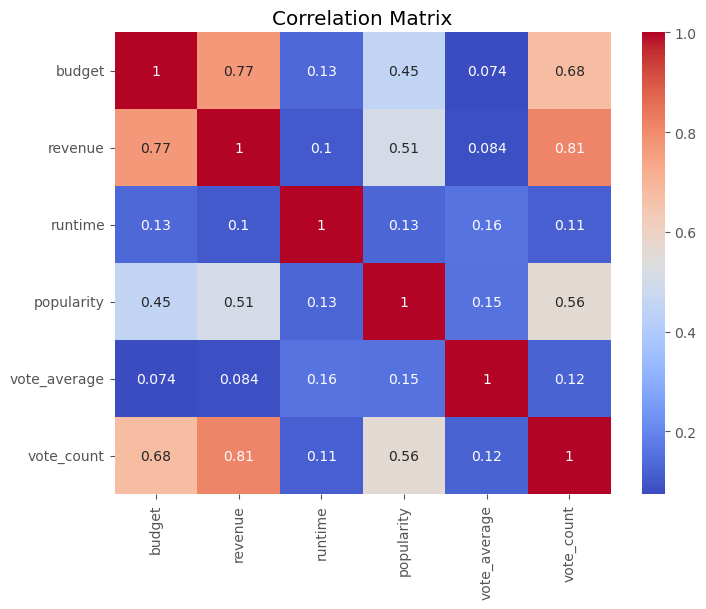

In [88]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix reveals relationships between numerical movie attributes.

For example:

- Budget and revenue often exhibit a positive relationship.
- Popularity is typically associated with higher vote counts.
- Vote average may show only a weak relationship with budget.

These insights provide context for understanding movie performance but are not directly used for collaborative filtering.

#### Highest Rated Movies

In [89]:
qualified_movies = movies[
    movies["vote_count"] >= 100
]

In [90]:
top_rated = qualified_movies[
    [
        "title",
        "vote_average",
        "vote_count"
    ]
].sort_values(
    by="vote_average",
    ascending=False
)

top_rated.head(20)

,title,vote_average,vote_count
10310,Dilwale Dulhania Le Jayenge,9.1,661.0
39079,Planet Earth,8.8,176.0
314,The Shawshank Redemption,8.5,8358.0
834,The Godfather,8.5,6024.0
40244,Your Name.,8.5,1030.0
13254,Dear Zachary: A Letter to a Son About His Father,8.4,146.0
1185,Once Upon a Time in America,8.3,1104.0
5482,Spirited Away,8.3,3968.0
44669,Black Mirror: White Christmas,8.3,211.0
23670,Whiplash,8.3,4376.0


### Interpretation

Applying a minimum vote threshold ensures that highly rated movies have sufficient audience support.

This prevents obscure movies with very few ratings from dominating the rankings.

#### Most Voted Movies

In [91]:
most_voted = movies[
    [
        "title",
        "vote_count"
    ]
].sort_values(
    by="vote_count",
    ascending=False
)

most_voted.head(20)

,title,vote_count
15481,Inception,14075.0
12482,The Dark Knight,12269.0
14552,Avatar,12114.0
17819,The Avengers,12000.0
26560,Deadpool,11444.0
22876,Interstellar,11187.0
20051,Django Unchained,10297.0
23750,Guardians of the Galaxy,10014.0
2843,Fight Club,9678.0
18245,The Hunger Games,9634.0


#### User Activity

In [92]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

user_activity.head(20)

userId
547    2391
564    1868
624    1735
15     1700
73     1610
452    1340
468    1291
380    1063
311    1019
30     1011
294     947
509     923
580     922
213     910
212     876
472     830
388     792
23      726
457     713
518     707
dtype: int64

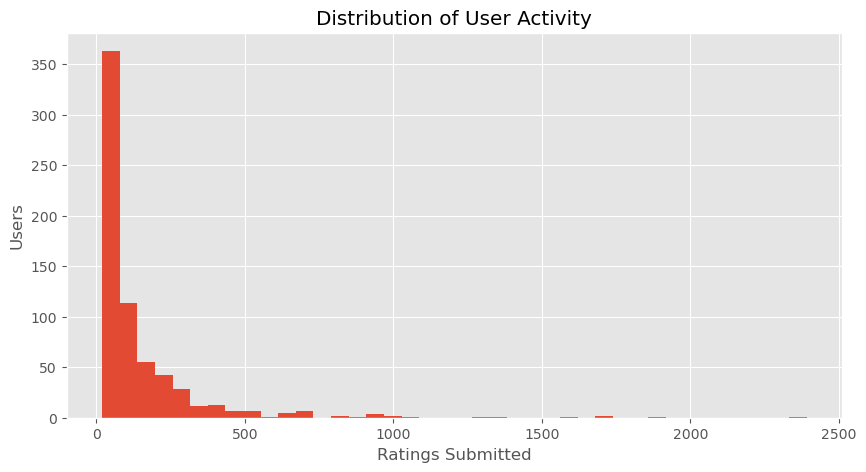

In [93]:
plt.figure(figsize=(10,5))

user_activity.hist(
    bins=40
)

plt.title("Distribution of User Activity")

plt.xlabel("Ratings Submitted")

plt.ylabel("Users")

plt.show()

### Interpretation

The majority of users contribute relatively few ratings, while a small group of highly active users contribute a disproportionately large number.

This sparsity is a defining characteristic of recommendation systems and motivates the use of collaborative filtering techniques capable of learning from incomplete user-item interactions.

# 6. Model 1: Popularity-Based Recommendation

## Overview

The popularity-based recommendation model suggests movies that are generally well-received by audiences.

Unlike personalized recommendation systems, this model does not require user history. Instead, it recommends movies based on overall popularity and audience ratings.

This approach is especially useful for:

- New users with no viewing history (cold-start problem)
- Homepage recommendations
- Trending movie sections
- Guest users

Although simple, popularity-based recommendation provides a strong baseline against which more advanced recommendation systems can be compared.

## Why Use Weighted Ratings?

Simply sorting movies by their average rating can produce misleading results because movies with only a few ratings may appear artificially high.

To address this issue, we use the IMDb weighted rating formula, which balances:

- Rating quality
- Number of audience votes

This produces rankings that are more reliable and representative of overall audience opinion.

#### Calculate Global Average Rating

In [94]:
# Calculate the overall average movie rating.
# This represents the baseline rating across all movies.

C = movies["vote_average"].mean()

print(f"Global average rating (C): {C:.2f}")

Global average rating (C): 5.62


#### Determine Minimum Vote Threshold
Why the 90th Percentile?

It adapts to the dataset instead of using a hardcoded value. If the dataset changes, the threshold changes automatically.

In [95]:
# Calculate the minimum vote threshold.
#
# Movies above this threshold are considered sufficiently
# popular for ranking.

m = movies["vote_count"].quantile(0.90)

print(f"Minimum vote threshold (m): {m:.0f}")

Minimum vote threshold (m): 160


#### Filter Qualified Movies

In [96]:
# Select movies with sufficient audience support.

qualified = movies[
    movies["vote_count"] >= m
].copy()

print(f"Qualified movies: {len(qualified):,}")

Qualified movies: 4,554


#### Create the Weighted Rating Function

In [97]:
# Function to calculate the IMDb weighted rating.

def weighted_rating(row, m=m, C=C):
    """
    Calculate the IMDb weighted rating.

    Parameters
    ----------
    row : pandas.Series

    Returns
    -------
    float
        Weighted movie score.
    """

    v = row["vote_count"]
    R = row["vote_average"]

    return (v / (v + m) * R) + (m / (v + m) * C)

#### Calculate Weighted Scores

In [98]:
# Compute weighted ratings for qualified movies.

qualified["weighted_rating"] = qualified.apply(
    weighted_rating,
    axis=1
)

qualified.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,director,keywords,metadata,release_year,weighted_rating
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000.0,"[animation, comedy, family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"led by woody, andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[tomhanks, timallen, donrickles]",johnlasseter,"[jealousy, toy, boy, friendship, friends, riva...",animation comedy family jealousy toy boy frien...,1995.0,7.640247
1,False,NaN,65000000.0,"[adventure, fantasy, family]",NaN,8844,tt0113497,en,Jumanji,when siblings judy and peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[robinwilliams, jonathanhyde, kirstendunst]",joejohnston,"[boardgame, disappearance, basedonchildren'sbo...",adventure fantasy family boardgame disappearan...,1995.0,6.820278
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0.0,[comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,just when george banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[Sandollar Productions, Touchstone Pictures]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[stevemartin, dianekeaton, martinshort]",charlesshyer,"[baby, midlifecrisis, confidence, aging, daugh...",comedy baby midlifecrisis confidence aging dau...,1995.0,5.660589
5,False,NaN,60000000.0,"[action, crime, drama, thriller]",NaN,949,tt0113277,en,Heat,"obsessive master thief, neil mccauley leads a ...",17.924927,/zMyfPUelumio3tiDKPffaUpsQTD.jpg,"[Regency Enterprises, Forward Pass, Warner Bros.]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0,"[alpacino, robertdeniro, valkilmer]",michaelmann,"[robbery, detective, bank, obsession, chase, s...",action crime drama thriller robbery detective ...,1995.0,7.537183
8,False,NaN,35000000.0,"[action, adventure, thriller]",NaN,9091,tt0114576,en,Sudden Death,international action superstar jean claude van...,5.231580,/eoWvKD60lT95Ss1MYNgVExpo5iU.jpg,"[Universal Pictures, Imperial Entertainment, S...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0,"[jean-claudevandamme, powersboothe, dorianhare...",peterhyams,"[terrorist, hostage, explosive, vicepresident]",action adventure thriller terrorist hostage ex...,1995.0,5.556516


In [99]:
# Display the top 20 recommended movies based on the weighted rating.

top_movies = qualified.sort_values(
    by="weighted_rating",
    ascending=False
)

top_movies[
    [
        "title",
        "vote_average",
        "vote_count",
        "weighted_rating"
    ]
].head(20)

,title,vote_average,vote_count,weighted_rating
314,The Shawshank Redemption,8.5,8358.0,8.445865
834,The Godfather,8.5,6024.0,8.425433
10310,Dilwale Dulhania Le Jayenge,9.1,661.0,8.421408
12482,The Dark Knight,8.3,12269.0,8.265474
2843,Fight Club,8.3,9678.0,8.256381
292,Pulp Fiction,8.3,8670.0,8.251402
522,Schindler's List,8.3,4436.0,8.206631
23670,Whiplash,8.3,4376.0,8.205396
5482,Spirited Away,8.3,3968.0,8.196046
2211,Life Is Beautiful,8.3,3643.0,8.187162


### Interpretation

The weighted ranking identifies movies that have both high audience ratings and substantial numbers of votes.

Unlike simple average ratings, this approach favors movies with strong and reliable audience support.

These movies form an excellent baseline recommendation list for new users who have not yet developed a viewing history.

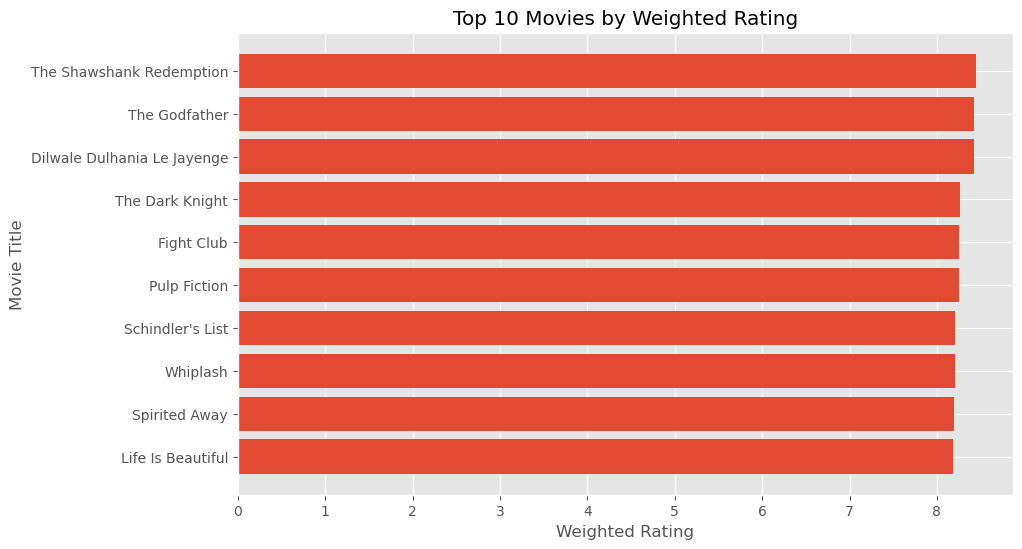

In [100]:
# Visualize the top 10 weighted recommendations.

top10 = top_movies.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["title"],
    top10["weighted_rating"]
)

plt.title("Top 10 Movies by Weighted Rating")

plt.xlabel("Weighted Rating")

plt.ylabel("Movie Title")

plt.gca().invert_yaxis()

plt.show()

## Business Interpretation

The popularity-based recommendation model provides Netflix with a simple yet effective solution for users who have little or no interaction history.

Although this approach does not personalize recommendations, it ensures that users are immediately presented with high-quality, broadly appealing content.

In a production environment, popularity-based recommendations are commonly used for:

- New user onboarding
- Trending sections
- Featured content
- Promotional campaigns
- Regional top charts

This model also serves as an important benchmark against which more advanced recommendation systems can be evaluated.

## Content-Based Recommendation

## Why TF-IDF?

The metadata feature created during feature engineering contains textual descriptions of each movie.

Machine learning algorithms cannot compare raw text directly.

Therefore, we first transform each movie into a numerical vector using **Term Frequency–Inverse Document Frequency (TF-IDF).**

TF-IDF assigns greater importance to words that are highly descriptive while reducing the influence of very common words.

For example:

- "christophernolan" carries substantial information.
- "movie" carries very little information.

This weighting enables more meaningful similarity comparisons.

#### Create the TF-IDF Matrix

In [101]:
# Convert movie metadata into numerical feature vectors
# using TF-IDF vectorization.


from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(
    movies["metadata"]
)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (45457, 150442)


## Why Cosine Similarity?

Once every movie has been represented as a numerical vector, we require a method to quantify how similar two movies are.

Cosine Similarity measures the angle between two vectors rather than their magnitude.

A similarity score close to **1** indicates that two movies have very similar characteristics.

A score close to **0** indicates that the movies share few descriptive features.

Cosine Similarity is widely used in recommendation systems because it performs well with high-dimensional sparse text data such as TF-IDF vectors.

In [102]:
# Compute pairwise cosine similarity between all movies.

from sklearn.metrics.pairwise import linear_kernel

cosine_sim = linear_kernel(
    tfidf_matrix,
    tfidf_matrix
)

print(cosine_sim.shape)

(45457, 45457)


#### Build the Movie Index

In [103]:
# Create a mapping from movie titles to DataFrame indices.

indices = pd.Series(
    movies.index,
    index=movies["title"]
).drop_duplicates()

print(f"Indexed {len(indices):,} movie titles.")

Indexed 45,457 movie titles.


#### Create a Unique Movie Label
Movie titles are not always unique. There can be remakes, films with the same name released in different years, or duplicates in the metadata.

In [104]:
# Create a unique movie label using title and release year.
# This helps distinguish movies with identical titles.

movies["movie_label"] = (
    movies["title"].fillna("Unknown Title")
    + " ("
    + movies["release_year"].fillna(0).astype(int).astype(str)
    + ")"
)

movies[["movie_label"]].head()

,movie_label
0,Toy Story (1995)
1,Jumanji (1995)
2,Grumpier Old Men (1995)
3,Waiting to Exhale (1995)
4,Father of the Bride Part II (1995)


In [105]:
# Build an index using the unique movie label.

indices = pd.Series(
    movies.index,
    index=movies["movie_label"]
).drop_duplicates()

print(f"Indexed {len(indices):,} unique movie labels.")

Indexed 45,457 unique movie labels.


# 7. Model 2: Content-Based Recommendation System

## Overview

Unlike popularity-based recommendation, content-based recommendation personalizes movie suggestions by recommending movies that are similar to a movie the user already likes.

The similarity is computed using the engineered movie metadata developed during feature engineering.

Each movie is represented using:

- Genres
- Keywords
- Cast
- Director
- Overview

These features are converted into TF-IDF vectors, and similarity between movies is measured using Cosine Similarity.

The resulting recommendation system identifies movies with similar characteristics regardless of their popularity.

#### Build the Recommendation Function

In [107]:
# Content-Based Recommendation Function
# ------------------------------------------------------------
# Returns the Top-N most similar movies for a given movie.

def recommend_movies(movie_title, cosine_sim=cosine_sim, top_n=10):
    """
    Recommend movies similar to a selected movie.

    Parameters
    ----------
    movie_title : str
        Movie title including release year.
        Example:
        "Toy Story (1995)"

    cosine_sim : ndarray
        Cosine similarity matrix.

    top_n : int
        Number of recommendations.

    Returns
    -------
    pandas.DataFrame
        Recommended movies ranked by similarity.
    """

    # Check whether the movie exists
    if movie_title not in indices.index:

        print(f'"{movie_title}" was not found.')

        return None

    # Retrieve movie index
    idx = indices[movie_title]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Sort scores from highest to lowest
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the movie itself
    similarity_scores = similarity_scores[1:top_n+1]

    # Retrieve recommended movie indices
    movie_indices = [
        i[0]
        for i in similarity_scores
    ]

    # Build recommendation dataframe
    recommendations = movies.iloc[movie_indices][
        [
            "title",
            "release_year",
            "genres",
            "director",
            "vote_average",
            "vote_count"
        ]
    ].copy()

    recommendations["Similarity Score"] = [
        round(score[1],3)
        for score in similarity_scores
    ]

    return recommendations.reset_index(drop=True)

#### Test the Recommender

In [108]:
recommend_movies(
    "Toy Story (1995)"
)

,title,release_year,genres,director,vote_average,vote_count,Similarity Score
0,Toy Story 2,1999.0,"[animation, comedy, family]",johnlasseter,7.3,3914.0,0.451
1,Toy Story 3,2010.0,"[animation, family, comedy]",leeunkrich,7.6,4710.0,0.433
2,Small Fry,2011.0,"[animation, family]",angusmaclane,6.8,118.0,0.245
3,The 40 Year Old Virgin,2005.0,"[comedy, romance]",juddapatow,6.2,2020.0,0.223
4,Andy Kaufman Plays Carnegie Hall,1980.0,[],,0.0,0.0,0.196
5,Andy Hardy's Blonde Trouble,1944.0,"[comedy, family, romance]",georgeb.seitz,6.3,2.0,0.194
6,Hot Splash,1988.0,[],jamesingrassia,4.0,1.0,0.189
7,The Champ,1931.0,[drama],kingvidor,6.8,13.0,0.173
8,Andy Peters: Exclamation Mark Question Point,2015.0,[comedy],stevenfeinartz,0.0,0.0,0.167
9,Toy Story of Terror!,2013.0,"[animation, comedy, family]",angusmaclane,7.3,246.0,0.150


In [109]:
recommend_movies(
    "The Dark Knight (2008)"
)

,title,release_year,genres,director,vote_average,vote_count,Similarity Score
0,The Dark Knight Rises,2012.0,"[action, crime, drama, thriller]",christophernolan,7.6,9263.0,0.418
1,Batman Returns,1992.0,"[action, fantasy]",timburton,6.6,1706.0,0.312
2,Batman Begins,2005.0,"[action, crime, drama]",christophernolan,7.5,7511.0,0.311
3,Batman: Under the Red Hood,2010.0,"[action, animation]",brandonvietti,7.6,459.0,0.300
4,"Batman: The Dark Knight Returns, Part 2",2013.0,"[action, animation]",jayoliva,7.9,426.0,0.266
5,Batman Beyond Darwyn Cooke's Batman 75th Anniv...,2014.0,"[action, animation, sciencefiction]",brucetimm,7.7,12.0,0.253
6,LEGO DC Comics Super Heroes: Batman: Be-Leaguered,2014.0,"[action, adventure, animation, family]",rickmorales,6.1,20.0,0.247
7,The Lego Batman Movie,2017.0,"[action, animation, comedy, family, fantasy]",chrismckay,7.2,1473.0,0.245
8,Batman Forever,1995.0,"[action, crime, fantasy]",joelschumacher,5.2,1529.0,0.243
9,Batman: The Killing Joke,2016.0,"[action, animation, crime, drama]",samliu,6.2,485.0,0.240


In [110]:
recommend_movies(
    "The Godfather (1972)"
)

,title,release_year,genres,director,vote_average,vote_count,Similarity Score
0,The Godfather: Part II,1974.0,"[drama, crime]",francisfordcoppola,8.3,3418.0,0.373
1,The Godfather Trilogy: 1972-1990,1992.0,[],,8.8,13.0,0.259
2,The Godfather: Part III,1990.0,"[crime, drama, thriller]",francisfordcoppola,7.1,1589.0,0.244
3,Election,2005.0,"[crime, drama]",johnnieto,6.7,51.0,0.114
4,The Most Beautiful Wife,1970.0,"[crime, drama]",damianodamiani,8.5,4.0,0.113
5,The Rain People,1969.0,[drama],francisfordcoppola,5.5,10.0,0.107
6,Trial by Jury,1994.0,"[drama, action, thriller]",heywoodgould,5.5,5.0,0.105
7,A Mother Should Be Loved,1934.0,[],yasujirōozu,0.0,0.0,0.102
8,Live by Night,2016.0,"[crime, drama]",benaffleck,6.2,416.0,0.102
9,The Don Is Dead,1973.0,"[crime, drama]",richardfleischer,5.6,5.0,0.101


In [111]:
recommend_movies(
    "Interstellar (2014)"
)

,title,release_year,genres,director,vote_average,vote_count,Similarity Score
0,Space Station 3D,2002.0,[documentary],tonimyers,6.1,11.0,0.180
1,Mission to Mir,1997.0,[documentary],ivangalin,3.0,2.0,0.159
2,Hubble 3D,2010.0,[documentary],tonimyers,6.7,41.0,0.131
3,Destiny in Space,1994.0,[documentary],benburtt,7.0,2.0,0.128
4,Solaris,2002.0,"[drama, sciencefiction, mystery, romance]",stevensoderbergh,5.9,378.0,0.125
5,Contact,1997.0,"[drama, sciencefiction, mystery]",robertzemeckis,7.2,1338.0,0.120
6,Apollo 13,1995.0,[drama],ronhoward,7.3,1637.0,0.117
7,Race to Space,2001.0,"[drama, family]",seanmcnamara,5.4,7.0,0.116
8,Journey to the Seventh Planet,1962.0,"[adventure, fantasy, horror, sciencefiction]",sidneyw.pink,4.4,15.0,0.116
9,Passage to Mars,2016.0,"[adventure, documentary, sciencefiction]",jean-christophejeauffre,4.8,4.0,0.114


#### Make the Function More User-Friendly

In [113]:
# Search helper function.
# Helps users locate the exact movie label.


def search_movie(keyword):

    results = movies[
        movies["title"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    ][
        [
            "movie_label",
            "release_year"
        ]
    ]

    return results.sort_values(
        by="release_year"
    )

In [114]:
search_movie(
    "Batman"
)

,movie_label,release_year
18140,Batman and Robin (1949),1949.0
8605,Batman (1966),1966.0
585,Batman (1989),1989.0
1329,Batman Returns (1992),1992.0
3095,Batman: Mask of the Phantasm (1993),1993.0
150,Batman Forever (1995),1995.0
1491,Batman & Robin (1997),1997.0
9141,Batman & Mr. Freeze: SubZero (1998),1998.0
9170,The Batman Superman Movie: World's Finest (1998),1998.0
44972,Batman Beyond: The Movie (1999),1999.0


## Qualitative Evaluation

The recommendations generated by the content-based recommender were inspected manually.

Movies recommended for a selected title generally shared several characteristics, including:

- Similar genres
- Common directors
- Shared lead actors
- Comparable story themes
- Similar plot keywords

These observations indicate that the feature engineering process successfully captured meaningful movie characteristics.

Although the recommendations are not personalized to individual users, they provide relevant suggestions based solely on movie content.

# Evaluation of the Content-Based Recommendation System

## Strengths

- Produces personalized recommendations based on movie characteristics.
- Does not require ratings from other users.
- Handles new movies well provided metadata is available.
- Easy to explain because recommendations are based on observable movie features.
- Suitable for users with limited interaction history.

---

## Limitations

- Can only recommend movies similar to those already watched.
- May produce recommendations that lack diversity.
- Cannot discover unexpected interests outside existing preferences.
- Recommendation quality depends heavily on metadata quality.

---

## Business Implications

Content-based recommendation improves personalization by matching users with movies that share similar themes, genres, actors, or directors.

Streaming platforms often combine this approach with collaborative filtering to increase recommendation diversity and overall user satisfaction.

# 8. Model 3: Collaborative Filtering Recommendation System

## Overview

Unlike content-based recommendation, collaborative filtering does not rely on movie descriptions such as genres, actors, or directors.

Instead, it learns from user behavior.

The underlying assumption is that users with similar viewing and rating patterns are likely to enjoy similar movies.

For example:

- If User A and User B both highly rate several of the same movies,
- and User A enjoys another movie that User B has not yet watched,

then that movie becomes a strong recommendation for User B.

Collaborative filtering is one of the most influential techniques used in modern recommendation systems because it captures hidden patterns in user preferences that cannot be identified using movie metadata alone.

## The User–Item Matrix

Collaborative filtering begins by organizing the ratings into a matrix.

Rows represent users.

Columns represent movies.

Each cell contains the rating a user assigned to a movie.

Most users rate only a small fraction of all available movies, meaning that the matrix contains many missing values.

This characteristic is referred to as **matrix sparsity**, and it is one of the central challenges in recommendation systems.

In [115]:
# Display the first few ratings.

ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [116]:
# Basic information about the ratings dataset.

print(f"Number of Ratings : {len(ratings):,}")

print(f"Unique Users      : {ratings['userId'].nunique():,}")

print(f"Unique Movies     : {ratings['movieId'].nunique():,}")

Number of Ratings : 100,004
Unique Users      : 671
Unique Movies     : 9,066


In [117]:
# Create the User–Movie matrix.

user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_movie_matrix.head()

movieId  1       2       3       4       5       6       7       8       9       10      11      12      13      14      15      16      17      18      19      20      21      22      23      24      25      26      27      28      29      30      31      32      34      35      36      37      38      39      40      41      42      43      44      45      46      47      48      49      50      52      53      54      55      57      58      59      60      61      62      63      64      65      66      68      69      70      71      72      73      74      76      77      78      79      80      81      82      83      84      85      86      87      88      89      92      93      94      95      96      97      98      99      100     101     102     103     104     105     107     108     110     111     112     113     114     116     117     118     119     121     122     123     124     125     126     129     130     131     132     135     137     140     141     144     145     146     147     148     149     150     151     152     153     154     155     156     157     158     159     160     161     162     163     164     165     166     167     168     \
userId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     2.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     4.0     NaN     NaN     NaN     NaN     NaN     NaN     5.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     5.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     4.0     NaN     NaN     4.0     3.0     NaN

In [118]:
# Calculate matrix sparsity.

total_cells = (
    user_movie_matrix.shape[0] *
    user_movie_matrix.shape[1]
)

filled_cells = user_movie_matrix.count().sum()

sparsity = (
    1 - filled_cells / total_cells
) * 100

print(f"Matrix Sparsity: {sparsity:.2f}%")

Matrix Sparsity: 98.36%


### Interpretation

The user-item matrix is highly sparse, meaning that most users have rated only a small subset of all available movies.

This sparsity makes recommendation challenging because the system must predict ratings for movies that users have never interacted with.

Matrix factorization techniques such as Singular Value Decomposition (SVD) are specifically designed to address this challenge.

## Why Singular Value Decomposition (SVD)?

Rather than memorizing every rating, SVD learns hidden patterns called **latent factors**.

Examples of latent factors may include:

- Preference for science fiction
- Preference for action movies
- Interest in animated films
- Appreciation for independent cinema

These factors are not explicitly provided in the dataset.

Instead, the algorithm discovers them by analyzing rating patterns across thousands of users and movies.

This enables the model to estimate how much a user is likely to enjoy a movie they have never rated.

In [119]:
# Install the Surprise recommendation library

!pip install scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.3 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 2.1 MB/s  0:00:01


In [120]:
# Import the Surprise library.

from surprise import Dataset
from surprise import Reader
from surprise import SVD

from surprise.model_selection import train_test_split
from surprise import accuracy

#### Prepare the Dataset

In [121]:
# Define the rating scale.

reader = Reader(
    rating_scale=(0.5, 5)
)

In [122]:
# Load the ratings DataFrame into Surprise.

data = Dataset.load_from_df(
    ratings[
        [
            "userId",
            "movieId",
            "rating"
        ]
    ],
    reader
)

In [123]:
# Split the ratings into training and testing sets.

trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

#### Train the SVD Model

In [124]:
# Initialize the SVD model.

svd_model = SVD(
    random_state=42
)

In [125]:
# Train the recommendation model.

svd_model.fit(trainset)

print("SVD training completed.")

SVD training completed.


# Evaluating the Collaborative Filtering Model

Training a recommendation model is only the first step.

The next objective is to determine how accurately the model predicts ratings that it has never seen before.

In this section, we evaluate the SVD model using standard recommendation system metrics before generating personalized movie recommendations.

#### Predict Ratings on the Test Set

In [126]:
# Generate predictions for the test dataset.

predictions = svd_model.test(testset)

print(f"Number of predictions: {len(predictions):,}")

Number of predictions: 20,001


In [127]:
# Inspect a few predictions

predictions[:5]

[Prediction(uid=15, iid=95875, r_ui=1.5, est=np.float64(2.54510601460441), details={'was_impossible': False}),
 Prediction(uid=664, iid=3081, r_ui=4.0, est=np.float64(3.776746798742076), details={'was_impossible': False}),
 Prediction(uid=171, iid=2770, r_ui=4.0, est=np.float64(3.469900710323008), details={'was_impossible': False}),
 Prediction(uid=355, iid=589, r_ui=4.0, est=np.float64(3.863832384796042), details={'was_impossible': False}),
 Prediction(uid=505, iid=86882, r_ui=5.0, est=np.float64(3.4888101051720084), details={'was_impossible': False})]

#### Evaluate Using RMSE

In [128]:
# Root Mean Squared Error

rmse = accuracy.rmse(
    predictions,
    verbose=True
)

RMSE: 0.9024


### Interpretation

Root Mean Squared Error (RMSE) measures the average difference between the true user ratings and the predicted ratings.

Lower RMSE values indicate better prediction performance.

An RMSE close to zero represents highly accurate predictions, while larger values indicate greater prediction errors.

#### Evaluate Using MAE

In [129]:
# Mean Absolute Error

mae = accuracy.mae(
    predictions,
    verbose=True
)

MAE:  0.6954


## Evaluation Metrics

Two complementary metrics were used to evaluate the collaborative filtering model.

### RMSE

Measures the square root of the average squared prediction error.

Large prediction errors are penalized more heavily.

### MAE

Measures the average absolute prediction error.

MAE is easier to interpret because it represents the average difference between predicted and actual ratings.

Using both metrics provides a balanced assessment of recommendation accuracy.

#### Predict One Rating

In [134]:
# Predict a single rating in a readable format.

user_id = 1
movie_id = 50

prediction = svd_model.predict(
    uid=user_id,
    iid=movie_id
)

print(f"User ID          : {user_id}")
print(f"Movie ID         : {movie_id}")
print(f"Predicted Rating : {prediction.est:.2f}")

User ID          : 1
Movie ID         : 50
Predicted Rating : 3.39


# Connecting MovieLens Ratings with Movie Metadata

The collaborative filtering model is trained using the MovieLens dataset, where movies are identified using **MovieLens IDs**.

However, the movie metadata (titles, genres, directors, etc.) comes from TMDB and uses **TMDB IDs**.

To present meaningful recommendations, we need a lookup table that connects these two identifier systems.

The `links_small.csv` dataset provides this mapping.

Once merged, the recommendation model can predict ratings using MovieLens IDs while displaying human-readable movie information from the metadata dataset.

In [135]:
# Load the MovieLens ↔ TMDB mapping dataset.

links_small = pd.read_csv("links_small.csv")

print(f"Shape: {links_small.shape}")

links_small.head()

Shape: (9125, 3)


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [136]:
# Clean the TMDB IDs.

links_small["tmdbId"] = pd.to_numeric(
    links_small["tmdbId"],
    errors="coerce"
)

links_small = links_small.dropna(subset=["tmdbId"])

links_small["tmdbId"] = links_small["tmdbId"].astype(int)

print("Missing TMDB IDs removed.")

Missing TMDB IDs removed.


#### Build the Lookup Table

In [137]:
# Merge MovieLens IDs with movie metadata.

movie_lookup = movies.merge(
    links_small,
    left_on="id",
    right_on="tmdbId",
    how="inner"
)

print(f"Lookup table shape: {movie_lookup.shape}")

movie_lookup.head()

Lookup table shape: (9099, 33)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,director,keywords,metadata,release_year,movie_label,movieId,imdbId,tmdbId
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000.0,"[animation, comedy, family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"led by woody, andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[tomhanks, timallen, donrickles]",johnlasseter,"[jealousy, toy, boy, friendship, friends, riva...",animation comedy family jealousy toy boy frien...,1995.0,Toy Story (1995),1,114709,862
1,False,NaN,65000000.0,"[adventure, fantasy, family]",NaN,8844,tt0113497,en,Jumanji,when siblings judy and peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[robinwilliams, jonathanhyde, kirstendunst]",joejohnston,"[boardgame, disappearance, basedonchildren'sbo...",adventure fantasy family boardgame disappearan...,1995.0,Jumanji (1995),2,113497,8844
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0.0,"[romance, comedy]",NaN,15602,tt0113228,en,Grumpier Old Men,a family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[waltermatthau, jacklemmon, ann-margret]",howarddeutch,"[fishing, bestfriend, duringcreditsstinger, ol...",romance comedy fishing bestfriend duringcredit...,1995.0,Grumpier Old Men (1995),3,113228,15602
3,False,NaN,16000000.0,"[comedy, drama, romance]",NaN,31357,tt0114885,en,Waiting to Exhale,"cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[Twentieth Century Fox Film Corporation],"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[whitneyhouston, angelabassett, lorettadevine]",forestwhitaker,"[basedonnovel, interracialrelationship, single...",comedy drama romance basedonnovel interracialr...,1995.0,Waiting to Exhale (1995),4,114885,31357
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0.0,[comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,just when george banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[Sandollar Productions, Touchstone Pictures]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[stevemartin, dianekeaton, martinshort]",charlesshyer,"[baby, midlifecrisis, confidence, aging, daugh...",comedy baby midlifecrisis confidence aging dau...,1995.0,Father of the Bride Part II (1995),5,113041,11862


In [138]:
movie_lookup[
    [
        "movieId",
        "title",
        "release_year"
    ]
].head()

,movieId,title,release_year
0,1,Toy Story,1995.0
1,2,Jumanji,1995.0
2,3,Grumpier Old Men,1995.0
3,4,Waiting to Exhale,1995.0
4,5,Father of the Bride Part II,1995.0


## Why is the Lookup Table Necessary?

The recommendation model predicts ratings using **MovieLens movie IDs**.

However, users expect recommendations to display movie titles rather than numerical identifiers.

The lookup table bridges this gap by linking each MovieLens movie ID to its corresponding movie metadata.

This integration enables the collaborative filtering model to produce recommendations that are both accurate and interpretable.

In [141]:
# Collaborative Filtering Recommendation Function

def recommend_for_user(user_id, top_n=10):
    """
    Generate personalized movie recommendations for a user
    using the trained SVD model.
    """

    # Movies already rated by the user
    rated_movies = ratings.loc[
        ratings["userId"] == user_id,
        "movieId"
    ].tolist()

    # Movies the user has not rated
    candidates = movie_lookup[
        ~movie_lookup["movieId"].isin(rated_movies)
    ].copy()

    # Predict ratings
    predicted_scores = []

    for movie_id in candidates["movieId"]:

        prediction = svd_model.predict(
            uid=user_id,
            iid=movie_id
        )

        predicted_scores.append(prediction.est)

    candidates["Predicted Rating"] = predicted_scores

    # Sort by predicted rating
    recommendations = candidates.sort_values(
        by="Predicted Rating",
        ascending=False
    )

    return recommendations[
        [
            "title",
            "release_year",
            "genres",
            "vote_average",
            "vote_count",
            "Predicted Rating"
        ]
    ].head(top_n).reset_index(drop=True)

#### Test the Recommender

In [142]:
recommend_for_user(
    user_id=1,
    top_n=10
)

,title,release_year,genres,vote_average,vote_count,Predicted Rating
0,The African Queen,1951.0,"[adventure, war, romance]",7.4,232.0,3.888561
1,The Godfather,1972.0,"[drama, crime]",8.5,6024.0,3.869988
2,Das Boot,1981.0,"[action, drama, history, war, adventure]",7.9,623.0,3.754281
3,Stand by Me,1986.0,"[crime, drama]",7.8,1568.0,3.735564
4,The Shawshank Redemption,1994.0,"[drama, crime]",8.5,8358.0,3.718731
5,Happiness,1998.0,"[comedy, drama]",7.4,197.0,3.717193
6,The Dark Knight,2008.0,"[drama, action, crime, thriller]",8.3,12269.0,3.680959
7,Lawrence of Arabia,1962.0,"[adventure, drama, history, war]",7.8,870.0,3.680950
8,Reservoir Dogs,1992.0,"[crime, thriller]",8.1,3821.0,3.673413
9,Nashville,1975.0,"[drama, music]",7.2,79.0,3.672566


In [143]:
recommend_for_user(5)

,title,release_year,genres,vote_average,vote_count,Predicted Rating
0,Ran,1985.0,"[action, drama, history]",7.9,349.0,4.669409
1,It Happened One Night,1934.0,"[comedy, romance]",7.7,283.0,4.652200
2,Run Lola Run,1998.0,"[action, drama, thriller]",7.2,672.0,4.644335
3,Cinema Paradiso,1988.0,"[drama, romance]",8.2,834.0,4.627689
4,The African Queen,1951.0,"[adventure, war, romance]",7.4,232.0,4.615592
5,Raging Bull,1980.0,[drama],7.7,968.0,4.613241
6,The Maltese Falcon,1941.0,"[mystery, crime, thriller]",7.8,435.0,4.612308
7,Roman Holiday,1953.0,"[comedy, romance]",7.8,502.0,4.610904
8,12 Angry Men,1957.0,[drama],8.2,2130.0,4.584241
9,Schindler's List,1993.0,"[drama, history, war]",8.3,4436.0,4.584191


In [144]:
recommend_for_user(25)

,title,release_year,genres,vote_average,vote_count,Predicted Rating
0,Schindler's List,1993.0,"[drama, history, war]",8.3,4436.0,4.366152
1,The African Queen,1951.0,"[adventure, war, romance]",7.4,232.0,4.348598
2,The Godfather,1972.0,"[drama, crime]",8.5,6024.0,4.279125
3,One Flew Over the Cuckoo's Nest,1975.0,[drama],8.3,3001.0,4.217979
4,It Happened One Night,1934.0,"[comedy, romance]",7.7,283.0,4.216913
5,Mister Roberts,1955.0,"[comedy, drama, family, war]",7.3,43.0,4.209912
6,The Shawshank Redemption,1994.0,"[drama, crime]",8.5,8358.0,4.204766
7,Singin' in the Rain,1952.0,"[comedy, music, romance]",7.9,747.0,4.179534
8,Vertigo,1958.0,"[mystery, romance, thriller]",8.0,1162.0,4.173771
9,Cinema Paradiso,1988.0,"[drama, romance]",8.2,834.0,4.169615


## Interpretation

Unlike the popularity-based recommendation model, collaborative filtering generates different recommendations for different users.

The model estimates ratings for movies a user has not yet watched by learning hidden preference patterns from historical rating behavior.

This enables the recommendation system to personalize movie suggestions without relying on movie metadata.

As a result, collaborative filtering can recommend movies that differ in genre, cast, or director but are nevertheless likely to align with a user's interests.

# 9. Model Comparison and Evaluation

Throughout this project, three different recommendation approaches were developed.

Each model addresses a different aspect of the recommendation problem and offers unique strengths and limitations.

Rather than replacing one another, these models complement each other and can be combined into a hybrid recommendation system.

This section compares the models from both technical and business perspectives.

In [145]:
# Compare the recommendation models.

comparison = pd.DataFrame({
    "Model":[
        "Popularity-Based",
        "Content-Based",
        "Collaborative Filtering"
    ],

    "Personalized":[
        "No",
        "Partially",
        "Yes"
    ],

    "Uses Metadata":[
        "No",
        "Yes",
        "No"
    ],

    "Uses User Ratings":[
        "No",
        "No",
        "Yes"
    ],

    "Cold Start":[
        "Excellent",
        "Moderate",
        "Poor"
    ],

    "Recommendation Diversity":[
        "Low",
        "Moderate",
        "High"
    ]
})

comparison

,Model,Personalized,Uses Metadata,Uses User Ratings,Cold Start,Recommendation Diversity
0,Popularity-Based,No,No,No,Excellent,Low
1,Content-Based,Partially,Yes,No,Moderate,Moderate
2,Collaborative Filtering,Yes,No,Yes,Poor,High


## Comparative Analysis

### Popularity-Based Recommendation

This model recommends movies that are highly rated by a large number of users.

It is particularly useful for:

- New users with no viewing history.
- Trending movie sections.
- Editorial recommendations.

However, every user receives essentially the same recommendations.

---

### Content-Based Recommendation

This model recommends movies that are similar to those a user has already enjoyed.

It successfully captures similarities in:

- Genres
- Plot keywords
- Directors
- Cast
- Movie descriptions

Its main limitation is that recommendations remain close to the user's previous interests and may lack diversity.

---

### Collaborative Filtering

Collaborative filtering provides the highest level of personalization.

Instead of analyzing movie characteristics, it learns from user behavior.

This enables the model to recommend movies that may appear unrelated but are frequently enjoyed by users with similar tastes.

Among the three models, collaborative filtering produces the most personalized recommendations.

## Recommendation System Evaluation

Although RMSE and MAE provide valuable information regarding rating prediction accuracy, they do not directly measure recommendation quality.

In industrial recommendation systems, additional ranking metrics are commonly used, including:

- Precision@K
- Recall@K
- Mean Average Precision (MAP)
- Normalized Discounted Cumulative Gain (NDCG)

These metrics evaluate how relevant the recommended movies are within the top recommendations presented to the user.

Due to the limited scope of this project and the available dataset, RMSE and MAE were used as the primary quantitative evaluation metrics, while recommendation relevance was assessed qualitatively through manual inspection.

# 13. Conclusion

The objective of this project was to develop a movie recommendation system capable of helping Netflix users discover movies they are likely to enjoy while reducing the time spent searching for content.

Following the CRISP-DM methodology, the project progressed through business understanding, data understanding, data preparation, exploratory data analysis, feature engineering, model development, evaluation, and business recommendations.

Three complementary recommendation systems were developed:

- A popularity-based recommender for cold-start users.
- A content-based recommender that recommends movies with similar characteristics.
- A collaborative filtering recommender that personalizes recommendations using historical user ratings.

Among the three approaches, collaborative filtering provided the highest level of personalization, while popularity-based recommendation effectively addressed the cold-start problem and content-based recommendation generated relevant movie-to-movie suggestions.

The findings demonstrate that recommendation systems are most effective when multiple approaches are combined into a hybrid architecture.

Overall, the project successfully addressed the business objective by developing a recommendation framework capable of improving content discovery, increasing user engagement, and supporting user retention.

In [146]:
# Demonstration of the Three Recommendation Models

print("=" * 60)
print("NETFLIX MOVIE RECOMMENDATION SYSTEM")
print("=" * 60)

print("\n1. Top 10 Popular Movies")
display(
    top_movies[
        ["title", "weighted_rating"]
    ].head(10)
)

print("\n2. Movies Similar to 'Toy Story (1995)'")
display(
    recommend_movies("Toy Story (1995)")
)

print("\n3. Personalized Recommendations for User 1")
display(
    recommend_for_user(user_id=1)
)

NETFLIX MOVIE RECOMMENDATION SYSTEM

1. Top 10 Popular Movies


,title,weighted_rating
314,The Shawshank Redemption,8.445865
834,The Godfather,8.425433
10310,Dilwale Dulhania Le Jayenge,8.421408
12482,The Dark Knight,8.265474
2843,Fight Club,8.256381
292,Pulp Fiction,8.251402
522,Schindler's List,8.206631
23670,Whiplash,8.205396
5482,Spirited Away,8.196046
2211,Life Is Beautiful,8.187162



2. Movies Similar to 'Toy Story (1995)'


,title,release_year,genres,director,vote_average,vote_count,Similarity Score
0,Toy Story 2,1999.0,"[animation, comedy, family]",johnlasseter,7.3,3914.0,0.451
1,Toy Story 3,2010.0,"[animation, family, comedy]",leeunkrich,7.6,4710.0,0.433
2,Small Fry,2011.0,"[animation, family]",angusmaclane,6.8,118.0,0.245
3,The 40 Year Old Virgin,2005.0,"[comedy, romance]",juddapatow,6.2,2020.0,0.223
4,Andy Kaufman Plays Carnegie Hall,1980.0,[],,0.0,0.0,0.196
5,Andy Hardy's Blonde Trouble,1944.0,"[comedy, family, romance]",georgeb.seitz,6.3,2.0,0.194
6,Hot Splash,1988.0,[],jamesingrassia,4.0,1.0,0.189
7,The Champ,1931.0,[drama],kingvidor,6.8,13.0,0.173
8,Andy Peters: Exclamation Mark Question Point,2015.0,[comedy],stevenfeinartz,0.0,0.0,0.167
9,Toy Story of Terror!,2013.0,"[animation, comedy, family]",angusmaclane,7.3,246.0,0.150



3. Personalized Recommendations for User 1


,title,release_year,genres,vote_average,vote_count,Predicted Rating
0,The African Queen,1951.0,"[adventure, war, romance]",7.4,232.0,3.888561
1,The Godfather,1972.0,"[drama, crime]",8.5,6024.0,3.869988
2,Das Boot,1981.0,"[action, drama, history, war, adventure]",7.9,623.0,3.754281
3,Stand by Me,1986.0,"[crime, drama]",7.8,1568.0,3.735564
4,The Shawshank Redemption,1994.0,"[drama, crime]",8.5,8358.0,3.718731
5,Happiness,1998.0,"[comedy, drama]",7.4,197.0,3.717193
6,The Dark Knight,2008.0,"[drama, action, crime, thriller]",8.3,12269.0,3.680959
7,Lawrence of Arabia,1962.0,"[adventure, drama, history, war]",7.8,870.0,3.680950
8,Reservoir Dogs,1992.0,"[crime, thriller]",8.1,3821.0,3.673413
9,Nashville,1975.0,"[drama, music]",7.2,79.0,3.672566
